# **6. Modelo Propuesto: CA-UNet++ con Plane Conditioning**

## Motivacion

El analisis de benchmarks de la Fase 5 identifico con precision empirica tres gaps que limitan el rendimiento de las arquitecturas estandar sobre BRISC 2025:

**Gap 1 -- Segmentacion de Glioma:** Los cinco modelos obtuvieron mIoU entre 66.6% y 68.3% para gliomas, frente al 74.0% de SaberNet (Fateh et al., 2026). Los bordes infiltrativos del glioma generan interfaces tumor-tejido sano de dificil delimitacion. Los encoders ResNet34 con skip connections planas carecen de mecanismos explicitos para suprimir el fondo dominante (~98% de pixeles) y enfocarse en las regiones de transicion borrosa.

**Gap 2 -- Degradacion consistente en el plano axial:** El patron Sagittal > Coronal > Axial se observo de forma invariante en los cinco benchmarks, con una brecha de ~3 puntos porcentuales entre extremos. Este patron es independiente de la arquitectura y responde a propiedades intrisecas de las imagenes (mayor proporcion de fondo en el plano axial, 53.4%). Ningun modelo benchmark aprovecha la informacion del plano anatomico para adaptar su estrategia.

**Gap 3 -- Proximidad al umbral de referencia:** El mejor benchmark (UNet++, 79.9% W-mIoU) se encuentra a solo 0.7 pp del objetivo (SaberNet, 80.6%). Se requieren mejoras precisas y bien motivadas sobre la arquitectura base, no una redesign completo.

## Estrategia de diseno

Se propone **CA-UNet++** (*Channel-Attention UNet++ with Plane Conditioning*), que extiende UNet++ mediante dos contribuciones modulares ortogonales:

1. **Modulos CBAM en las skip connections** (Woo et al., 2018): aplican atencion secuencial de canal y espacial sobre cada skip connection, atacando directamente el Gap 1.

2. **Plane Conditioning mediante FiLM** (Perez et al., 2018): inyecta la informacion del plano anatomico como condicion sobre las features del bottleneck, atacando directamente el Gap 2.

## Protocolo de ablacion

Para cuantificar la contribucion independiente de cada modulo, se entrenan tres variantes bajo condiciones identicas. El Weighted mIoU de UNet++ (79.9%) de la Fase 5 actua como baseline sin necesidad de re-entrenamiento:

| Variante | Backbone | CBAM | Plane Cond. |
|----------|:--------:|:----:|:-----------:|
| **CA-UNet++ (+CBAM)** | UNet++ | Si | No |
| **CA-UNet++ (+Plane)** | UNet++ | No | Si |
| **CA-UNet++ (Full)** | UNet++ | Si | Si |

## 6.1 Configuracion del Entorno

Se importan las mismas dependencias de la Fase 5 para garantizar consistencia experimental. El limite de epochs se incrementa de 100 a 150 para acomodar la convergencia mas lenta esperada en arquitecturas con modulos de atencion y conditioning.

In [24]:
# ============================================================
# 1. CONFIGURACION DEL ENTORNO
# ============================================================

import os, time, copy, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy import stats

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import GradScaler, autocast
from PIL import Image
import albumentations as A
from albumentations.pytorch import ToTensorV2
import segmentation_models_pytorch as smp

SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False
warnings.filterwarnings("ignore")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("  CONFIGURACION DEL ENTORNO -- MODELO PROPUESTO")
print("=" * 60)
print(f"  PyTorch:  {torch.__version__}")
print(f"  SMP:      {smp.__version__}")
print(f"  Device:   {device}")
if torch.cuda.is_available():
    print(f"  GPU:    {torch.cuda.get_device_name(0)}")
    print(f"  VRAM:   {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
print(f"  Seed:     {SEED}")
print("=" * 60)


  CONFIGURACION DEL ENTORNO -- MODELO PROPUESTO
  PyTorch:  2.5.1+cu121
  SMP:      0.5.0
  Device:   cuda
  GPU:    NVIDIA GeForce RTX 3050 Laptop GPU
  VRAM:   4.0 GB
  Seed:     42


## 6.2 Carga de Datos y DataLoaders

Se reutilizan los splits persistidos en disco durante la Fase 4 y el mismo pipeline de preprocesamiento y augmentacion. La unica diferencia respecto a la Fase 5 es que el Dataset retorna el indice numerico del plano anatomico (`plane_idx`) en el meta-diccionario, necesario para el modulo de Plane Conditioning: Axial=0, Coronal=1, Sagittal=2.

In [25]:
# ============================================================
# 2. CARGA DE DATOS Y DATALOADERS
# ============================================================

base_path = r"C:\Users\johan\Downloads\Proyectos academicos\imagenes_tumores_cerebrales\brisc2025"

IMG_SIZE    = 256
BATCH_SIZE  = 16
NUM_WORKERS = 0
PIN_MEMORY  = True

PLANE_TO_IDX = {"Axial": 0, "Coronal": 1, "Sagittal": 2}

df_train = pd.read_csv(os.path.join(base_path, "split_train.csv"))
df_val   = pd.read_csv(os.path.join(base_path, "split_val.csv"))
df_test  = pd.read_csv(os.path.join(base_path, "split_test.csv"))
print(f"Splits: Train={len(df_train)} | Val={len(df_val)} | Test={len(df_test)}")


class BRISCSegDataset(Dataset):
    """
    Dataset BRISC 2025 extendido con plane_idx para conditioning.
    Retorna (image, mask, meta) donde meta["plane_idx"] es el
    indice entero del plano: Axial=0, Coronal=1, Sagittal=2.
    """
    def __init__(self, dataframe, transforms=None):
        self.df = dataframe.reset_index(drop=True)
        self.transforms = transforms

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = np.array(
            Image.open(row["image_path"]).convert("L"), dtype=np.float32
        ) / 255.0
        mask = np.array(
            Image.open(row["mask_path"]).convert("L"), dtype=np.float32
        ) / 255.0
        mask = (mask > 0.5).astype(np.float32)

        if self.transforms:
            t     = self.transforms(image=image, mask=mask)
            image = t["image"]
            mask  = t["mask"]
        else:
            image = torch.from_numpy(image)
            mask  = torch.from_numpy(mask)

        if image.ndim == 2: image = image.unsqueeze(0)
        if mask.ndim  == 2: mask  = mask.unsqueeze(0)

        meta = {
            "filename":    row["filename"],
            "tumor_label": row["tumor_label"],
            "plane_label": row["plane_label"],
            "plane_idx":   torch.tensor(
                PLANE_TO_IDX.get(row["plane_label"], 0), dtype=torch.long),
        }
        return image, mask, meta


train_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1,
                       rotate_limit=15, border_mode=0, p=0.4),
    A.ElasticTransform(alpha=50, sigma=10, border_mode=0, p=0.2),
    A.RandomBrightnessContrast(brightness_limit=0.15,
                                contrast_limit=0.15, p=0.4),
    A.GaussNoise(var_limit=(5.0, 25.0), p=0.3),
    A.GaussianBlur(blur_limit=(3, 5), p=0.2),
    ToTensorV2(),
])
val_test_transforms = A.Compose([
    A.Resize(IMG_SIZE, IMG_SIZE),
    ToTensorV2(),
])

train_dataset = BRISCSegDataset(df_train, transforms=train_transforms)
val_dataset   = BRISCSegDataset(df_val,   transforms=val_test_transforms)
test_dataset  = BRISCSegDataset(df_test,  transforms=val_test_transforms)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print(f"DataLoaders: Train={len(train_loader)} batches | "
      f"Val={len(val_loader)} | Test={len(test_loader)}")
print(f"Plane conditioning indices: {PLANE_TO_IDX}")


Splits: Train=3146 | Val=787 | Test=860
DataLoaders: Train=196 batches | Val=50 | Test=54
Plane conditioning indices: {'Axial': 0, 'Coronal': 1, 'Sagittal': 2}


## 6.3 Funciones de Perdida y Metricas

Se mantienen identicas la ComboLoss (alpha=0.5 Dice + 0.5 BCE) y las funciones de calculo de IoU y Dice de la Fase 5. Esta consistencia es requisito metodologico: cualquier diferencia de rendimiento observada es atribuible exclusivamente a la arquitectura.

In [26]:
# ============================================================
# 3. FUNCIONES DE PERDIDA Y METRICAS (identicas a Fase 5)
# ============================================================

class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
    def forward(self, pred, target):
        pred = torch.sigmoid(pred)
        p, t = pred.view(-1), target.view(-1)
        inter = (p * t).sum()
        return 1.0 - (2. * inter + self.smooth) / (p.sum() + t.sum() + self.smooth)


class ComboLoss(nn.Module):
    def __init__(self, alpha=0.5, smooth=1.0):
        super().__init__()
        self.alpha = alpha
        self.dice  = DiceLoss(smooth=smooth)
        self.bce   = nn.BCEWithLogitsLoss()
    def forward(self, pred, target):
        return self.alpha * self.dice(pred, target) + (1 - self.alpha) * self.bce(pred, target)


def compute_iou(pred, target, threshold=0.5, smooth=1e-6):
    p     = (torch.sigmoid(pred) > threshold).float()
    inter = (p * target).sum(dim=(1, 2, 3))
    union = p.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3)) - inter
    return (inter + smooth) / (union + smooth)


def compute_dice(pred, target, threshold=0.5, smooth=1e-6):
    p     = (torch.sigmoid(pred) > threshold).float()
    inter = (p * target).sum(dim=(1, 2, 3))
    return (2. * inter + smooth) / (p.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3)) + smooth)


print("ComboLoss, compute_iou, compute_dice definidas (identicas a Fase 5).")


ComboLoss, compute_iou, compute_dice definidas (identicas a Fase 5).


## 6.4 Arquitectura del Modelo Propuesto: CA-UNet++

### 6.4.1 Modulo CBAM (Convolutional Block Attention Module)

El CBAM (Woo et al., 2018) aplica dos sub-modulos secuenciales sobre un tensor F de features:

**Atencion de canal** M_c: aprende *que canales* son relevantes combinando pooling global promedio y maximo a traves de una MLP compartida:

    M_c(F) = sigmoid( MLP(AvgPool(F)) + MLP(MaxPool(F)) )

**Atencion espacial** M_s: aprende *donde* son relevantes las features sobre la representacion ya refinada por M_c:

    M_s(F') = sigmoid( conv7x7( [AvgPool(F'); MaxPool(F')] ) )

La salida es F'' = M_s * (M_c * F). En CA-UNet++, los CBAM se aplican sobre cada skip connection antes de que el decoder las reciba, permitiendo suprimir el fondo dominante (~98% de pixeles) y enfocarse en las transiciones borrosas del glioma.

### 6.4.2 Modulo de Plane Conditioning (FiLM)

El mecanismo FiLM (Perez et al., 2018) condiciona las features sobre una variable auxiliar -- el plano anatomico -- mediante una transformacion afin aprendida:

    FiLM(F | p) = (1 + gamma(p)) * F + beta(p)

donde gamma(p) y beta(p) son vectores generados por una red auxiliar a partir del embedding del plano p in {Axial, Coronal, Sagittal}. Se aplica en el bottleneck (512 canales).

### 6.4.3 Integracion en UNet++

Ambos modulos son controlados por flags booleanos `use_cbam` y `use_plane`, lo que permite generar las tres variantes de ablacion desde un unico modulo.

In [27]:
# ============================================================
# 4. ARQUITECTURA CA-UNet++
# ============================================================

class ChannelAttention(nn.Module):
    """Atencion de canal: que features importan."""
    def __init__(self, in_ch, r=16):
        super().__init__()
        mid = max(in_ch // r, 8)
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_ch, mid), nn.ReLU(inplace=True),
            nn.Linear(mid, in_ch),
        )
    def forward(self, x):
        avg = self.mlp(F.adaptive_avg_pool2d(x, 1))
        mx  = self.mlp(F.adaptive_max_pool2d(x, 1))
        return torch.sigmoid(avg + mx).unsqueeze(-1).unsqueeze(-1)


class SpatialAttention(nn.Module):
    """Atencion espacial: donde importan las features."""
    def __init__(self, k=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=k, padding=k//2, bias=False)
    def forward(self, x):
        avg = x.mean(dim=1, keepdim=True)
        mx  = x.max(dim=1,  keepdim=True).values
        return torch.sigmoid(self.conv(torch.cat([avg, mx], dim=1)))


class CBAM(nn.Module):
    """Convolutional Block Attention Module (Woo et al., 2018)."""
    def __init__(self, in_ch, r=16, k=7):
        super().__init__()
        self.ca = ChannelAttention(in_ch, r)
        self.sa = SpatialAttention(k)
    def forward(self, x):
        x = x * self.ca(x)
        x = x * self.sa(x)
        return x


class PlaneConditioningFiLM(nn.Module):
    """Feature-wise Linear Modulation condicionado en el plano anatomico.
    FiLM(F|p) = (1 + gamma(p)) * F + beta(p)
    """
    def __init__(self, num_planes=3, feature_dim=512, embed_dim=64):
        super().__init__()
        self.emb       = nn.Embedding(num_planes, embed_dim)
        self.gamma_net = nn.Sequential(
            nn.Linear(embed_dim, feature_dim), nn.ReLU(inplace=True),
            nn.Linear(feature_dim, feature_dim),
        )
        self.beta_net  = nn.Sequential(
            nn.Linear(embed_dim, feature_dim), nn.ReLU(inplace=True),
            nn.Linear(feature_dim, feature_dim),
        )
    def forward(self, x, plane_idx):
        e     = self.emb(plane_idx)
        gamma = self.gamma_net(e).unsqueeze(-1).unsqueeze(-1)
        beta  = self.beta_net(e).unsqueeze(-1).unsqueeze(-1)
        return (1 + gamma) * x + beta


class CAUNetPlusPlus(nn.Module):
    """CA-UNet++: UNet++ + CBAM en skip connections
    + Plane Conditioning (FiLM) en el bottleneck.
    Flags use_cbam y use_plane controlan las variantes de ablacion.
    """
    ENCODER_CHANNELS = [64, 64, 128, 256, 512]

    def __init__(self, in_channels=1, classes=1,
                 encoder_name="resnet34",
                 use_cbam=True, use_plane=True,
                 num_planes=3):
        super().__init__()
        self.use_cbam  = use_cbam
        self.use_plane = use_plane

        self.backbone = smp.UnetPlusPlus(
            encoder_name    = encoder_name,
            encoder_weights = "imagenet",
            in_channels     = in_channels,
            classes         = classes,
            activation      = None,
        )
        if self.use_cbam:
            self.cbam_blocks = nn.ModuleList([
                CBAM(ch) for ch in self.ENCODER_CHANNELS])
        if self.use_plane:
            self.plane_film = PlaneConditioningFiLM(
                num_planes=num_planes, feature_dim=512, embed_dim=64)

    def _apply_cbam(self, features):
        out = [features[0]]
        for i, feat in enumerate(features[1:]):
            out.append(self.cbam_blocks[i](feat) if i < len(self.cbam_blocks) else feat)
        return out

    def forward(self, x, plane_idx=None):
        features = self.backbone.encoder(x)
        if self.use_cbam:
            features = self._apply_cbam(features)
        if self.use_plane and plane_idx is not None:
            fl = list(features)
            fl[-1] = self.plane_film(fl[-1], plane_idx)
            features = fl
        dec    = self.backbone.decoder(features)
        logits = self.backbone.segmentation_head(dec)
        return logits


print("Arquitectura CA-UNet++ definida.")
print("  Backbone:   UNet++ + ResNet34 (ImageNet)")
print("  CBAM:       5 modulos sobre skip connections")
print("  Plane FiLM: embedding 3->64->512, bottleneck")


Arquitectura CA-UNet++ definida.
  Backbone:   UNet++ + ResNet34 (ImageNet)
  CBAM:       5 modulos sobre skip connections
  Plane FiLM: embedding 3->64->512, bottleneck


## 6.5 Verificacion de la Arquitectura

Se verifica que las tres variantes se construyen correctamente, que el overhead de parametros de CBAM y FiLM es menor al 5% respecto al backbone, y que el forward pass produce tensores (B,1,H,W) en todos los casos.

In [28]:
# ============================================================
# 5. VERIFICACION DE LA ARQUITECTURA
# ============================================================

def count_params(model):
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable


variants_check = {
    "UNet++ (Baseline, ref)":  CAUNetPlusPlus(use_cbam=False, use_plane=False),
    "CA-UNet++ (+CBAM)":       CAUNetPlusPlus(use_cbam=True,  use_plane=False),
    "CA-UNet++ (+Plane)":      CAUNetPlusPlus(use_cbam=False, use_plane=True),
    "CA-UNet++ (Full)":        CAUNetPlusPlus(use_cbam=True,  use_plane=True),
}

print("=" * 72)
print("  VERIFICACION DE ARQUITECTURAS")
print("=" * 72)
print(f"  {'Variante':<28} {'Params':>14} {'Trainable':>14} {'Overhead':>10}")
print("  " + "-" * 70)

base_p = None
for name, model in variants_check.items():
    total, train_p = count_params(model)
    if base_p is None:
        base_p   = total
        overhead = "baseline"
    else:
        overhead = f"+{(total - base_p) / base_p * 100:.1f}%"
    print(f"  {name:<28} {total:>14,} {train_p:>14,} {overhead:>10}")

print("\n  Test forward pass:")
dummy_img = torch.zeros(2, 1, 256, 256)
dummy_pl  = torch.tensor([0, 2], dtype=torch.long)
for name, model in variants_check.items():
    model.eval()
    with torch.no_grad():
        out = model(dummy_img, plane_idx=dummy_pl) if model.use_plane else model(dummy_img)
    ok = "OK" if out.shape == (2, 1, 256, 256) else "ERROR"
    print(f"    {ok}  {name:<32}  output: {tuple(out.shape)}")
print("\n  Todas las variantes producen tensores (B, 1, 256, 256).")


  VERIFICACION DE ARQUITECTURAS
  Variante                             Params      Trainable   Overhead
  ----------------------------------------------------------------------
  UNet++ (Baseline, ref)           26,072,337     26,072,337   baseline
  CA-UNet++ (+CBAM)                26,118,979     26,118,979      +0.2%
  CA-UNet++ (+Plane)               26,664,401     26,664,401      +2.3%
  CA-UNet++ (Full)                 26,711,043     26,711,043      +2.4%

  Test forward pass:
    OK  UNet++ (Baseline, ref)            output: (2, 1, 256, 256)
    OK  CA-UNet++ (+CBAM)                 output: (2, 1, 256, 256)
    OK  CA-UNet++ (+Plane)                output: (2, 1, 256, 256)
    OK  CA-UNet++ (Full)                  output: (2, 1, 256, 256)

  Todas las variantes producen tensores (B, 1, 256, 256).


## 6.6 Motor de Entrenamiento Adaptado

El motor de la Fase 5 se adapta para pasar `plane_idx` al modelo en cada batch. Para variantes sin conditioning, el argumento se ignora internamente. El limite de epochs se incrementa a 150; el resto de hiperparametros es identico a la Fase 5.

In [29]:
# ============================================================
# 6. MOTOR DE ENTRENAMIENTO ADAPTADO
# ============================================================

HPARAMS = {
    "max_epochs":         150,
    "patience":            15,
    "learning_rate":      1e-4,
    "weight_decay":       1e-4,
    "scheduler_patience":   5,
    "scheduler_factor":   0.5,
    "min_lr":             1e-7,
}
print("Hiperparametros del modelo propuesto:")
for k, v in HPARAMS.items():
    note = "  <- incrementado de 100" if k == "max_epochs" else ""
    print(f"   {k}: {v}{note}")


def train_one_epoch(model, loader, criterion, optimizer, scaler, device):
    model.train()
    loss_acc = iou_acc = dice_acc = nb = 0
    for imgs, masks, meta in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        pidx = meta["plane_idx"].to(device)
        optimizer.zero_grad()
        with torch.amp.autocast("cuda"):
            out  = model(imgs, plane_idx=pidx)
            loss = criterion(out, masks)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        with torch.no_grad():
            loss_acc += loss.item()
            iou_acc  += compute_iou(out, masks).mean().item()
            dice_acc += compute_dice(out, masks).mean().item()
            nb       += 1
    return {"loss": loss_acc/nb, "iou": iou_acc/nb, "dice": dice_acc/nb}


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    model.eval()
    loss_acc = iou_acc = dice_acc = nb = 0
    for imgs, masks, meta in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        pidx = meta["plane_idx"].to(device)
        with torch.amp.autocast("cuda"):
            out  = model(imgs, plane_idx=pidx)
            loss = criterion(out, masks)
        loss_acc += loss.item()
        iou_acc  += compute_iou(out, masks).mean().item()
        dice_acc += compute_dice(out, masks).mean().item()
        nb       += 1
    return {"loss": loss_acc/nb, "iou": iou_acc/nb, "dice": dice_acc/nb}


def train_model(model, name, train_loader, val_loader, device, hparams=HPARAMS):
    print(f"\n{'='*65}")
    print(f"  ENTRENAMIENTO: {name}")
    print(f"{'='*65}")
    total_p, train_p = count_params(model)
    print(f"  Params totales:    {total_p:>12,}")
    print(f"  Params trainables: {train_p:>12,}")
    print(f"  Tamano modelo:     {total_p * 4 / 1024**2:>10.1f} MB")

    model     = model.to(device)
    criterion = ComboLoss(alpha=0.5)
    optimizer = optim.AdamW(model.parameters(),
                             lr=hparams["learning_rate"],
                             weight_decay=hparams["weight_decay"])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max",
        factor=hparams["scheduler_factor"],
        patience=hparams["scheduler_patience"],
        min_lr=hparams["min_lr"], verbose=False)
    scaler = GradScaler("cuda")

    history = {k: [] for k in [
        "train_loss","train_iou","train_dice",
        "val_loss",  "val_iou",  "val_dice", "lr"]}

    best_dice = 0.0; best_state = None
    pat_cnt   = 0;   best_ep    = 0

    ckpt_dir    = os.path.join(base_path, "checkpoints")
    results_dir = os.path.join(base_path, "results")
    os.makedirs(ckpt_dir,    exist_ok=True)
    os.makedirs(results_dir, exist_ok=True)

    t0 = time.time()
    for ep in range(1, hparams["max_epochs"] + 1):
        te  = time.time()
        trm = train_one_epoch(model, train_loader, criterion, optimizer, scaler, device)
        vlm = evaluate(model, val_loader, criterion, device)
        lr  = optimizer.param_groups[0]["lr"]
        scheduler.step(vlm["dice"])

        for k in ["loss","iou","dice"]:
            history[f"train_{k}"].append(trm[k])
            history[f"val_{k}"].append(vlm[k])
        history["lr"].append(lr)

        improved = vlm["dice"] > best_dice
        if improved:
            best_dice  = vlm["dice"]
            best_state = copy.deepcopy(model.state_dict())
            best_ep    = ep
            pat_cnt    = 0
            marker     = " * BEST"
            torch.save({"epoch": ep, "model_state_dict": best_state,
                        "val_dice": best_dice, "val_iou": vlm["iou"],
                        "use_cbam": model.use_cbam, "use_plane": model.use_plane},
                       os.path.join(ckpt_dir, f"{name}_best.pth"))
        else:
            pat_cnt += 1
            marker   = f" (pat: {pat_cnt}/{hparams['patience']})"

        print(f"  Ep {ep:3d}/{hparams['max_epochs']} | "
              f"Tr Loss:{trm['loss']:.4f} IoU:{trm['iou']:.4f} Dice:{trm['dice']:.4f} | "
              f"Vl Loss:{vlm['loss']:.4f} IoU:{vlm['iou']:.4f} Dice:{vlm['dice']:.4f} | "
              f"LR:{lr:.1e} | {time.time()-te:.1f}s{marker}")

        if pat_cnt >= hparams["patience"]:
            print(f"\n  Early Stopping en ep {ep}. "
                  f"Mejor: ep {best_ep} (Dice {best_dice:.4f})")
            break

    model.load_state_dict(best_state)
    safe = name.lower().replace(" ","_").replace("+","plus").replace("(","").replace(")","_")
    hist_path = os.path.join(results_dir, f"{safe}_history.json")
    with open(hist_path, "w") as f: json.dump(history, f, indent=2)

    print(f"\n  Resumen -- {name}")
    print(f"  Mejor epoch:    {best_ep}")
    print(f"  Mejor Val Dice: {best_dice:.4f}")
    print(f"  Val IoU:        {history['val_iou'][best_ep-1]:.4f}")
    print(f"  Tiempo total:   {(time.time()-t0)/60:.1f} min")
    return model, history


print("\n Motor de entrenamiento definido.")


Hiperparametros del modelo propuesto:
   max_epochs: 150  <- incrementado de 100
   patience: 15
   learning_rate: 0.0001
   weight_decay: 0.0001
   scheduler_patience: 5
   scheduler_factor: 0.5
   min_lr: 1e-07

 Motor de entrenamiento definido.


## 6.7 Funciones Auxiliares: Guardado, Carga y Evaluacion Detallada

Las funciones de guardado y carga siguen el mismo patron que en la Fase 5. La funcion de evaluacion detallada calcula metricas desagregadas por tipo tumoral y plano anatomico, generando los datos necesarios para la tabla de ablacion y el analisis de significancia estadistica.

In [30]:
# ============================================================
# 7. FUNCIONES AUXILIARES
# ============================================================

def safe_name(name):
    return (name.lower()
            .replace(" ","_").replace("+","plus")
            .replace("(","").replace(")",""))


@torch.no_grad()
def evaluate_detailed(model, loader, device, model_name):
    """Evaluacion detallada con metricas por tumor y por plano.
    Retorna ademas el DataFrame de resultados por imagen,
    necesario para los tests estadisticos de la ablacion.
    """
    model.eval()
    rows = []
    for imgs, masks, meta in loader:
        imgs, masks = imgs.to(device), masks.to(device)
        pidx = meta["plane_idx"].to(device)
        with autocast(device_type="cuda"):
            out = model(imgs, plane_idx=pidx)
        ious  = compute_iou(out, masks)
        dices = compute_dice(out, masks)
        for i in range(len(imgs)):
            rows.append({
                "filename":    meta["filename"][i],
                "tumor_label": meta["tumor_label"][i],
                "plane_label": meta["plane_label"][i],
                "iou":         ious[i].item(),
                "dice":        dices[i].item(),
            })
    df = pd.DataFrame(rows)
    t_iou  = df.groupby("tumor_label")["iou"].mean()
    t_cnt  = df.groupby("tumor_label")["iou"].count()
    w_miou = (t_iou * t_cnt / t_cnt.sum()).sum()
    p_iou  = df.groupby("plane_label")["iou"].mean()
    cross  = df.groupby(["tumor_label","plane_label"])["iou"].mean()
    summary = {
        "model_name":    model_name,
        "global_iou":    df["iou"].mean(),
        "global_dice":   df["dice"].mean(),
        "weighted_miou": w_miou,
        "tumor_iou":     t_iou.to_dict(),
        "plane_iou":     p_iou.to_dict(),
        "cross_iou":     cross.to_dict(),
        "tumor_dice":    df.groupby("tumor_label")["dice"].mean().to_dict(),
        "plane_dice":    df.groupby("plane_label")["dice"].mean().to_dict(),
    }
    print(f"\n{'='*60}")
    print(f"  RESULTADOS EN TEST -- {model_name}")
    print(f"{'='*60}")
    print(f"  Weighted mIoU: {w_miou*100:.2f}%")
    print(f"  Global Dice:   {df['dice'].mean()*100:.2f}%")
    print("\n  mIoU por Tipo Tumoral:")
    for t, v in t_iou.items(): print(f"    {t:<12}: {v*100:.2f}%")
    print("\n  mIoU por Plano Anatomico:")
    for p, v in p_iou.items(): print(f"    {p:<10}: {v*100:.2f}%")
    return df, summary


def save_results(name, model, history, test_loader, device, base_path):
    results_dir = os.path.join(base_path, "results")
    os.makedirs(results_dir, exist_ok=True)
    sn = safe_name(name)
    df, summ = evaluate_detailed(model, test_loader, device, name)
    df.to_csv(os.path.join(results_dir, f"{sn}_test_results.csv"), index=False)
    summ_s = {k: ({str(kk): vv for kk,vv in v.items()} if isinstance(v, dict) else v)
              for k, v in summ.items()}
    with open(os.path.join(results_dir, f"{sn}_summary.json"), "w") as f:
        json.dump(summ_s, f, indent=2)
    print(f"  Resultados de {name} guardados ({len(df)} imagenes).")
    return df, summ


def already_trained(name, base_path):
    sn   = safe_name(name)
    ckpt = os.path.join(base_path, "checkpoints", f"{name}_best.pth")
    summ = os.path.join(base_path, "results",     f"{sn}_summary.json")
    hist = os.path.join(base_path, "results",     f"{sn}_history.json")
    ok   = all(os.path.exists(p) for p in [ckpt, summ, hist])
    if ok:
        ck = torch.load(ckpt, map_location="cpu", weights_only=True)
        print(f"  {name} encontrado -- Val Dice: {ck['val_dice']:.4f} (ep {ck['epoch']})")
    return ok


def load_results(name, base_path):
    sn  = safe_name(name)
    rd  = os.path.join(base_path, "results")
    with open(os.path.join(rd, f"{sn}_history.json")) as f: hist = json.load(f)
    with open(os.path.join(rd, f"{sn}_summary.json")) as f: summ = json.load(f)
    df  = pd.read_csv(os.path.join(rd, f"{sn}_test_results.csv"))
    print(f"  Cargado: {len(df)} imagenes, {len(hist['train_loss'])} epochs")
    return hist, summ, df


def load_checkpoint(build_fn, name, base_path, device):
    ck = torch.load(os.path.join(base_path, "checkpoints", f"{name}_best.pth"),
                    map_location=device, weights_only=True)
    m  = build_fn()
    m.load_state_dict(ck["model_state_dict"])
    m  = m.to(device).eval()
    print(f"  {name} cargado (Val Dice: {ck['val_dice']:.4f})")
    return m


print("Funciones auxiliares definidas.")


Funciones auxiliares definidas.


## 6.8 Funciones de Visualizacion

Se definen las funciones de curvas de entrenamiento y predicciones con codigo de colores (TP verde, FN rojo, FP azul). La funcion `visualize_best_worst` carga cada modelo desde checkpoint para generar las predicciones mejores y peores, liberando VRAM despues de cada modelo.

In [31]:
# ============================================================
# 8. FUNCIONES DE VISUALIZACION
# ============================================================

def plot_curves(history, name):
    """Curvas de entrenamiento con linea del mejor epoch."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    eps    = range(1, len(history["train_loss"]) + 1)
    best_e = int(np.argmax(history["val_dice"])) + 1
    for ax, tr, vl, lbl in zip(
        axes,
        ["train_loss","train_iou","train_dice"],
        ["val_loss",  "val_iou",  "val_dice"],
        ["Loss","IoU","Dice Score"]
    ):
        ax.plot(eps, history[tr], "b-", label="Train",      linewidth=1.5)
        ax.plot(eps, history[vl], "r-", label="Validation", linewidth=1.5)
        ax.axvline(best_e, color="green", ls="--", alpha=0.7,
                   label=f"Best ep ({best_e})")
        ax.set_title(f"{name} -- {lbl}")
        ax.set_xlabel("Epoch"); ax.set_ylabel(lbl)
        ax.legend(); ax.grid(True, alpha=0.3)
    plt.suptitle(f"Curvas de Entrenamiento -- {name}", fontsize=14, y=1.02)
    plt.tight_layout()
    sn = safe_name(name)
    plt.savefig(f"proposed_{sn}_curves.png", dpi=150, bbox_inches="tight")
    plt.show()


@torch.no_grad()
def visualize_best_worst(model, results_df, df_test_ref, device, name, n=5):
    """
    Visualiza las n mejores y peores predicciones segun IoU.
    Carga las imagenes desde disco usando los paths del df de test.
    """
    model.eval()
    rp = results_df.merge(
        df_test_ref[["filename","image_path","mask_path"]], on="filename", how="left")

    best  = rp.nlargest(n,  "iou")
    worst = rp.nsmallest(n, "iou")

    for subset, title in [(best, "MEJORES"), (worst, "PEORES")]:
        fig, axes = plt.subplots(n, 4, figsize=(16, n * 3))
        for i, (_, row) in enumerate(subset.iterrows()):
            img  = np.array(Image.open(row["image_path"]).convert("L"), dtype=np.float32) / 255.0
            gt   = np.array(Image.open(row["mask_path"]).convert("L"),  dtype=np.float32) / 255.0
            gt   = (gt > 0.5).astype(np.float32)

            # Preprocesar y predecir
            t    = val_test_transforms(image=img, mask=gt)
            img_t = t["image"].unsqueeze(0).to(device)
            pidx  = torch.tensor(
                [PLANE_TO_IDX.get(row["plane_label"], 0)], dtype=torch.long).to(device)
            with torch.amp.autocast("cuda"):
                out  = model(img_t, plane_idx=pidx)
            pred = (torch.sigmoid(out) > 0.5).float().cpu().squeeze().numpy()
            img_np = t["image"].squeeze().numpy()
            gt_np  = t["mask"].squeeze().numpy()

            ov = np.stack([img_np, img_np, img_np], axis=-1)
            tp = (gt_np==1)&(pred==1); fn = (gt_np==1)&(pred==0); fp = (gt_np==0)&(pred==1)
            ov[tp]=[0.0,0.8,0.0]; ov[fn]=[0.9,0.0,0.0]; ov[fp]=[0.0,0.3,0.9]

            axes[i,0].imshow(img_np, cmap="gray")
            axes[i,0].set_title(f"{row['tumor_label']} / {row['plane_label']}", fontsize=9)
            axes[i,0].axis("off")
            axes[i,1].imshow(gt_np, cmap="gray")
            axes[i,1].set_title("Ground Truth", fontsize=9)
            axes[i,1].axis("off")
            axes[i,2].imshow(pred, cmap="gray")
            axes[i,2].set_title("Prediccion", fontsize=9)
            axes[i,2].axis("off")
            axes[i,3].imshow(np.clip(ov,0,1))
            axes[i,3].set_title(f"IoU: {row['iou']*100:.1f}%", fontsize=9)
            axes[i,3].axis("off")

        for ax, t in zip(axes[0], ["Imagen MRI","Ground Truth","Prediccion","Overlay (TP/FN/FP)"]):
            ax.set_title(t, fontsize=10, fontweight="bold")
        fig.suptitle(f"{title} PREDICCIONES -- {name}", fontsize=13, y=1.01)
        plt.tight_layout()
        sn = safe_name(name)
        plt.savefig(f"proposed_{sn}_{title.lower()}.png", dpi=150, bbox_inches="tight")
        plt.show()


print("Funciones de visualizacion definidas.")


Funciones de visualizacion definidas.


## 6.9 Entrenamiento -- Variante 1: +CBAM

El objetivo es cuantificar la contribucion aislada del mecanismo de atencion CBAM sobre el rendimiento global y, especificamente, sobre la segmentacion de gliomas.

In [32]:
# ============================================================
# ENTRENAMIENTO: CA-UNet++ (+CBAM)
# ============================================================

_name  = "CA-UNet++ (+CBAM)"
# Corregido: usamos guiones bajos en el nombre de la función lambda
_build_ca_unetplusplus_pluscbam = lambda: CAUNetPlusPlus(use_cbam=True, use_plane=False)

if already_trained(_name, base_path):
    print(f"\n  {_name} ya entrenado. Cargando desde disco...")
    # Corregido: nombres de variables sin '-' ni '+'
    _history_ca_unetplusplus_pluscbam, _summary_ca_unetplusplus_pluscbam, _results_ca_unetplusplus_pluscbam = load_results(_name, base_path)
else:
    _model = _build_ca_unetplusplus_pluscbam()
    _model, _history_ca_unetplusplus_pluscbam = train_model(
        _model, _name, train_loader, val_loader, device)
    _results_ca_unetplusplus_pluscbam, _summary_ca_unetplusplus_pluscbam = save_results(
        _name, _model, _history_ca_unetplusplus_pluscbam, test_loader, device, base_path)
    del _model; torch.cuda.empty_cache()
    print(f"  VRAM liberada.")

# Acumular para tabla de ablacion
ablation_summaries = globals().get("ablation_summaries", {})
ablation_histories = globals().get("ablation_histories", {})
ablation_results   = globals().get("ablation_results",   {})

# Usamos las variables corregidas
ablation_summaries[_name] = _summary_ca_unetplusplus_pluscbam
ablation_histories[_name] = _history_ca_unetplusplus_pluscbam
ablation_results[_name]   = _results_ca_unetplusplus_pluscbam
print(f"\n {_name} completado.")



  ENTRENAMIENTO: CA-UNet++ (+CBAM)
  Params totales:      26,118,979
  Params trainables:   26,118,979
  Tamano modelo:           99.6 MB
  Ep   1/150 | Tr Loss:0.5846 IoU:0.3807 Dice:0.4941 | Vl Loss:0.4924 IoU:0.5500 Dice:0.6719 | LR:1.0e-04 | 116.2s * BEST
  Ep   2/150 | Tr Loss:0.4207 IoU:0.5426 Dice:0.6571 | Vl Loss:0.3339 IoU:0.5996 Dice:0.7172 | LR:1.0e-04 | 105.4s * BEST
  Ep   3/150 | Tr Loss:0.2640 IoU:0.5942 Dice:0.6947 | Vl Loss:0.1783 IoU:0.6962 Dice:0.7893 | LR:1.0e-04 | 105.4s * BEST
  Ep   4/150 | Tr Loss:0.1793 IoU:0.6261 Dice:0.7161 | Vl Loss:0.1307 IoU:0.7141 Dice:0.8021 | LR:1.0e-04 | 104.6s * BEST
  Ep   5/150 | Tr Loss:0.1491 IoU:0.6385 Dice:0.7259 | Vl Loss:0.1217 IoU:0.6735 Dice:0.7560 | LR:1.0e-04 | 104.4s (pat: 1/15)
  Ep   6/150 | Tr Loss:0.1349 IoU:0.6501 Dice:0.7335 | Vl Loss:0.1074 IoU:0.7236 Dice:0.8104 | LR:1.0e-04 | 104.9s * BEST
  Ep   7/150 | Tr Loss:0.1251 IoU:0.6627 Dice:0.7451 | Vl Loss:0.1037 IoU:0.7090 Dice:0.7933 | LR:1.0e-04 | 104.8s (pat: 1/1

### 6.9.1 Curvas de Entrenamiento y Predicciones: Variante 1: +CBAM

Se visualizan las curvas de convergencia y las mejores/peores predicciones del modelo sobre el set de test, cargando el checkpoint desde disco.

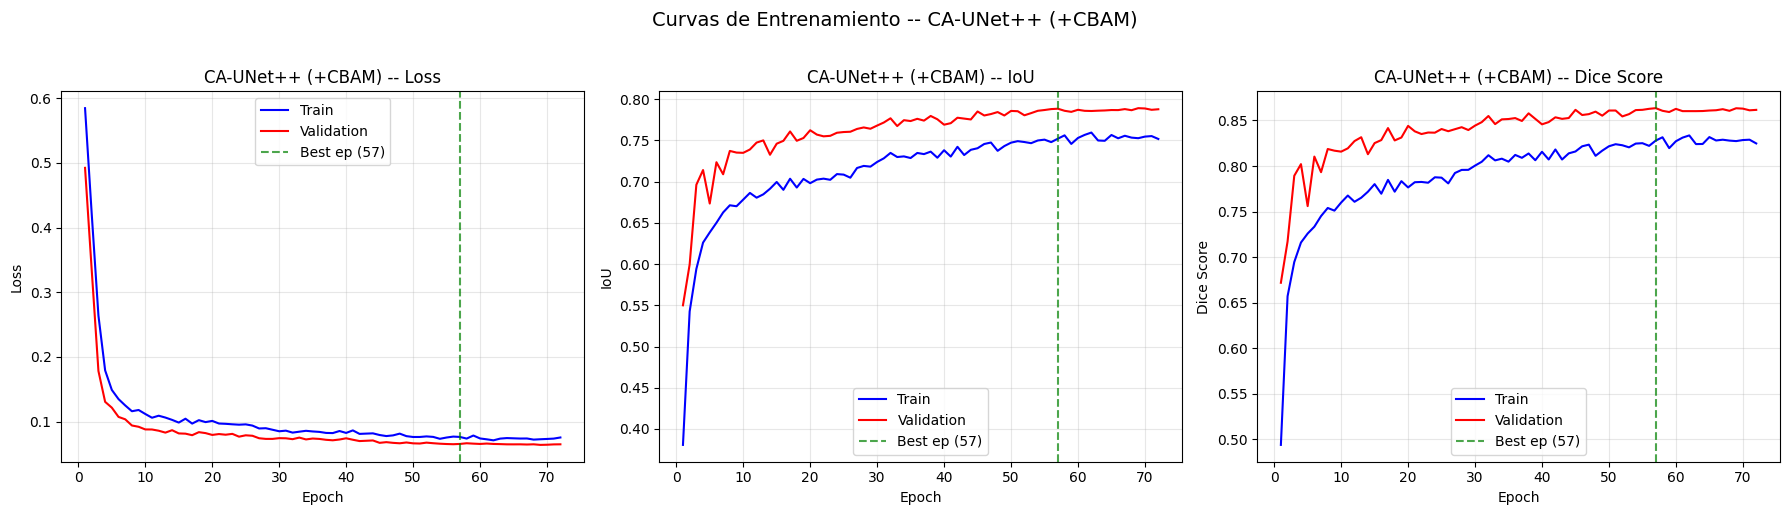


Cargando modelo para visualizacion de predicciones...
  CA-UNet++ (+CBAM) cargado (Val Dice: 0.8635)


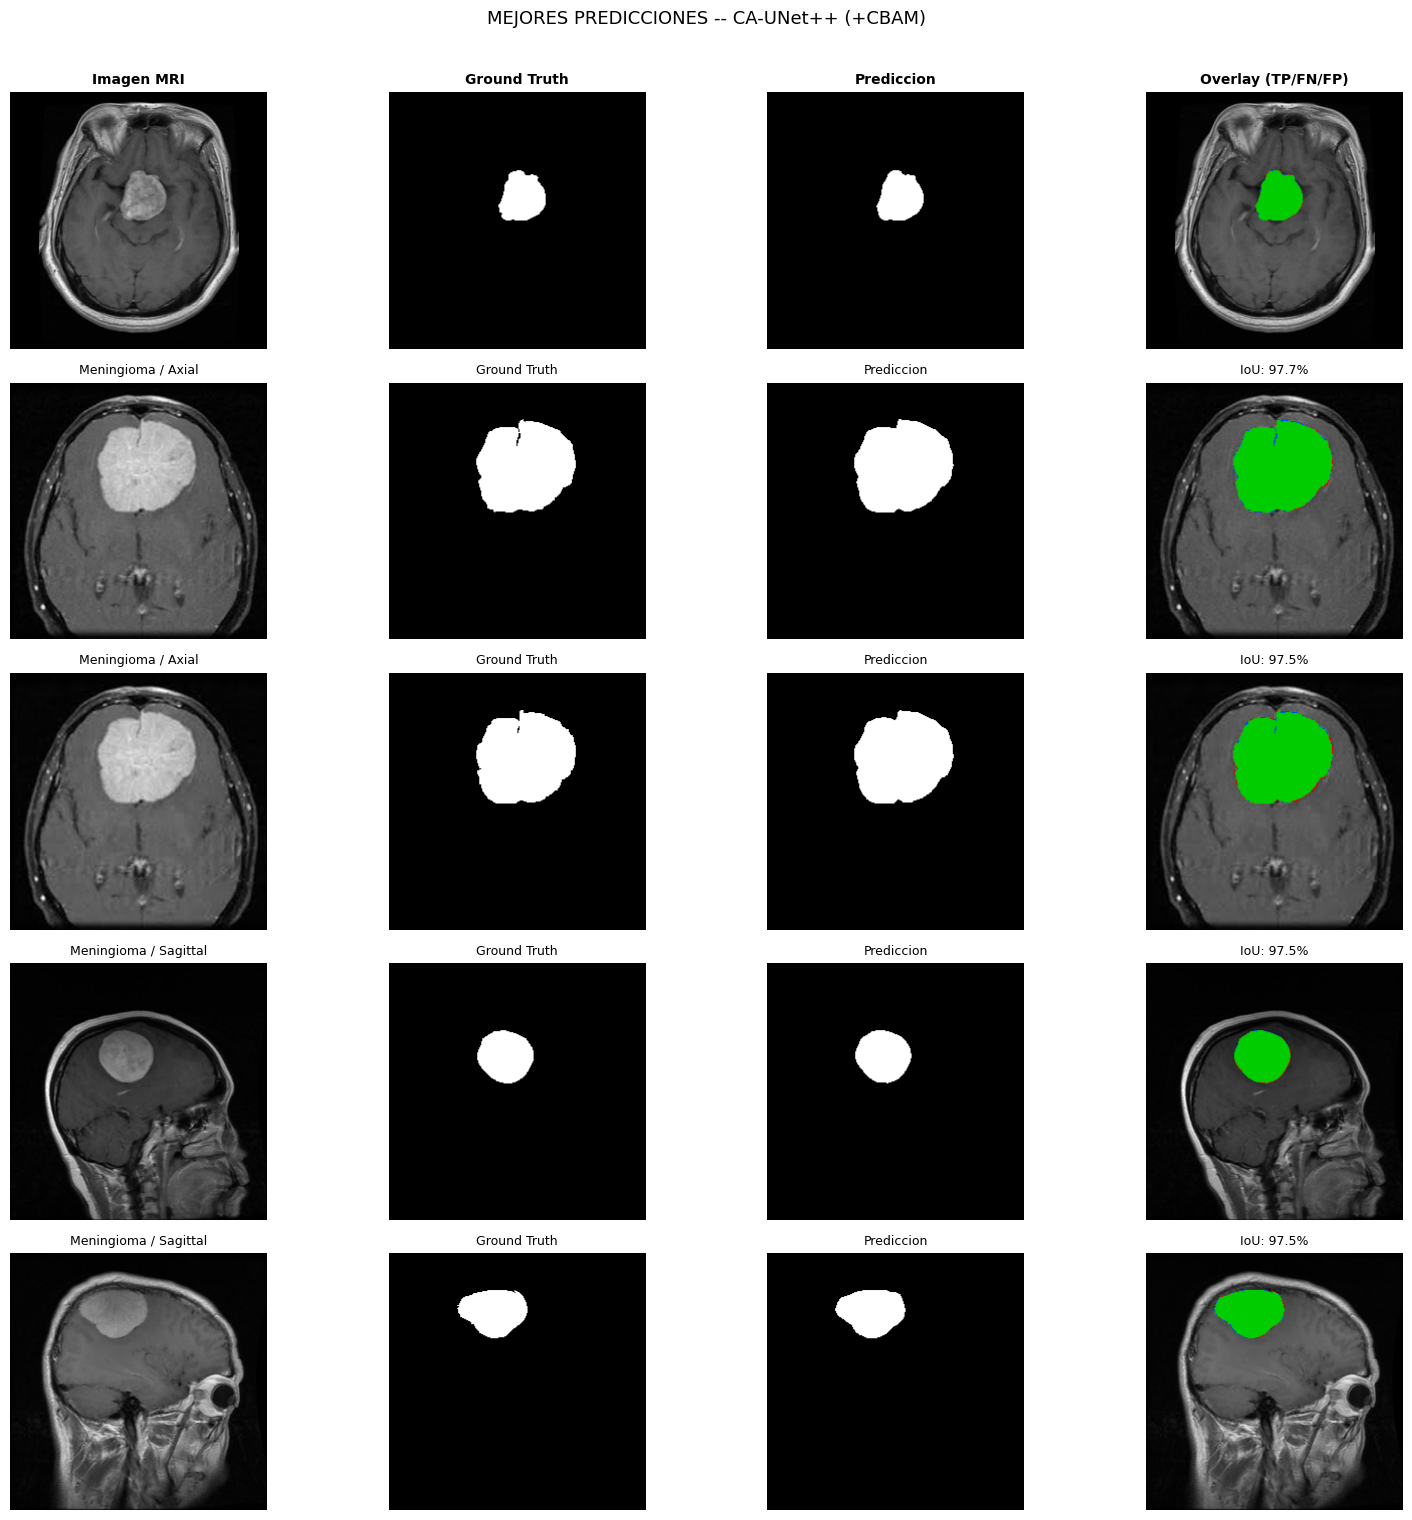

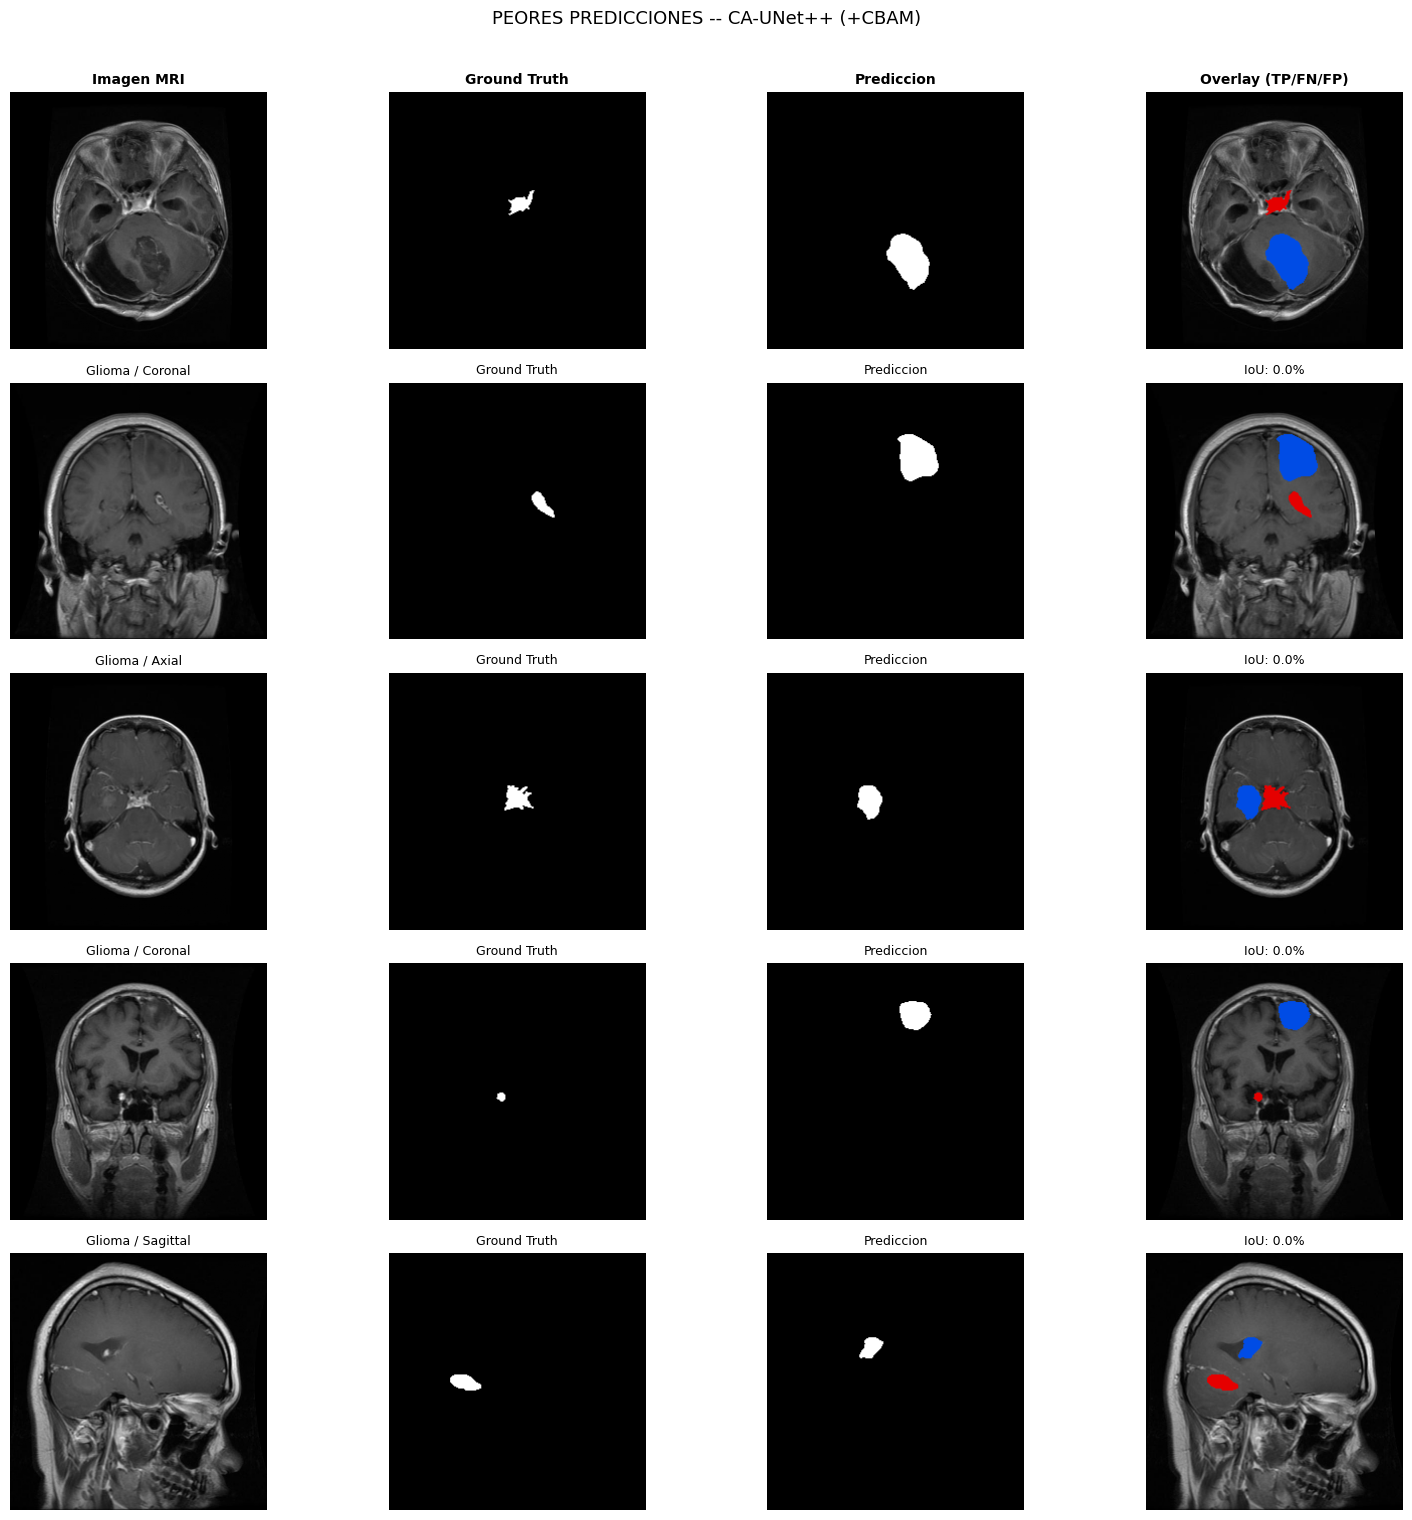

VRAM liberada.


In [33]:
# ============================================================
# VISUALIZACION: CA-UNet++ (+CBAM)
# ============================================================

# Corregido: _history_ca_unetplusplus_pluscbam
plot_curves(_history_ca_unetplusplus_pluscbam, "CA-UNet++ (+CBAM)")

print("\nCargando modelo para visualizacion de predicciones...")

# Corregido: _build_ca_unetplusplus_pluscbam
_vis_model = load_checkpoint(_build_ca_unetplusplus_pluscbam, "CA-UNet++ (+CBAM)", base_path, device)

# Corregido: _results_ca_unetplusplus_pluscbam
visualize_best_worst(
    _vis_model, _results_ca_unetplusplus_pluscbam, df_test, device, "CA-UNet++ (+CBAM)", n=5)

del _vis_model; torch.cuda.empty_cache()
print("VRAM liberada.")


## 6.10 Entrenamiento -- Variante 2: +Plane Conditioning

El objetivo es cuantificar si el Plane Conditioning (FiLM) reduce la brecha de rendimiento entre planos anatomicos sin modificar las skip connections.

In [34]:
# ============================================================
# ENTRENAMIENTO: CA-UNet++ (+Plane)
# ============================================================

_name  = "CA-UNet++ (+Plane)"
# Corregido: _build_ca_unetplusplus_plusplane
_build_ca_unetplusplus_plusplane = lambda: CAUNetPlusPlus(use_cbam=False, use_plane=True)

if already_trained(_name, base_path):
    print(f"\n  {_name} ya entrenado. Cargando desde disco...")
    # Corregido: nombres de variables con guiones bajos
    _history_ca_unetplusplus_plusplane, _summary_ca_unetplusplus_plusplane, _results_ca_unetplusplus_plusplane = load_results(_name, base_path)
else:
    _model = _build_ca_unetplusplus_plusplane()
    _model, _history_ca_unetplusplus_plusplane = train_model(
        _model, _name, train_loader, val_loader, device)
    _results_ca_unetplusplus_plusplane, _summary_ca_unetplusplus_plusplane = save_results(
        _name, _model, _history_ca_unetplusplus_plusplane, test_loader, device, base_path)
    del _model; torch.cuda.empty_cache()
    print(f"  VRAM liberada.")

# Acumular para tabla de ablacion
ablation_summaries = globals().get("ablation_summaries", {})
ablation_histories = globals().get("ablation_histories", {})
ablation_results   = globals().get("ablation_results",   {})

# Corregido: asignación a los diccionarios usando las nuevas variables
ablation_summaries[_name] = _summary_ca_unetplusplus_plusplane
ablation_histories[_name] = _history_ca_unetplusplus_plusplane
ablation_results[_name]   = _results_ca_unetplusplus_plusplane

print(f"\n {_name} completado.")



  ENTRENAMIENTO: CA-UNet++ (+Plane)
  Params totales:      26,664,401
  Params trainables:   26,664,401
  Tamano modelo:          101.7 MB
  Ep   1/150 | Tr Loss:0.7349 IoU:0.2154 Dice:0.3071 | Vl Loss:0.6189 IoU:0.5058 Dice:0.6338 | LR:1.0e-04 | 101.2s * BEST
  Ep   2/150 | Tr Loss:0.5659 IoU:0.5123 Dice:0.6290 | Vl Loss:0.5096 IoU:0.6020 Dice:0.7187 | LR:1.0e-04 | 99.4s * BEST
  Ep   3/150 | Tr Loss:0.4742 IoU:0.5473 Dice:0.6601 | Vl Loss:0.4221 IoU:0.6123 Dice:0.7254 | LR:1.0e-04 | 99.2s * BEST
  Ep   4/150 | Tr Loss:0.3870 IoU:0.5918 Dice:0.6952 | Vl Loss:0.3222 IoU:0.6772 Dice:0.7771 | LR:1.0e-04 | 99.0s * BEST
  Ep   5/150 | Tr Loss:0.2820 IoU:0.6186 Dice:0.7150 | Vl Loss:0.2167 IoU:0.6815 Dice:0.7757 | LR:1.0e-04 | 99.4s (pat: 1/15)
  Ep   6/150 | Tr Loss:0.2012 IoU:0.6276 Dice:0.7178 | Vl Loss:0.1510 IoU:0.7101 Dice:0.7956 | LR:1.0e-04 | 99.5s * BEST
  Ep   7/150 | Tr Loss:0.1605 IoU:0.6452 Dice:0.7306 | Vl Loss:0.1235 IoU:0.7206 Dice:0.8093 | LR:1.0e-04 | 98.4s * BEST
  Ep   

### 6.10.1 Curvas de Entrenamiento y Predicciones: Variante 2: +Plane Conditioning

Se visualizan las curvas de convergencia y las mejores/peores predicciones del modelo sobre el set de test, cargando el checkpoint desde disco.

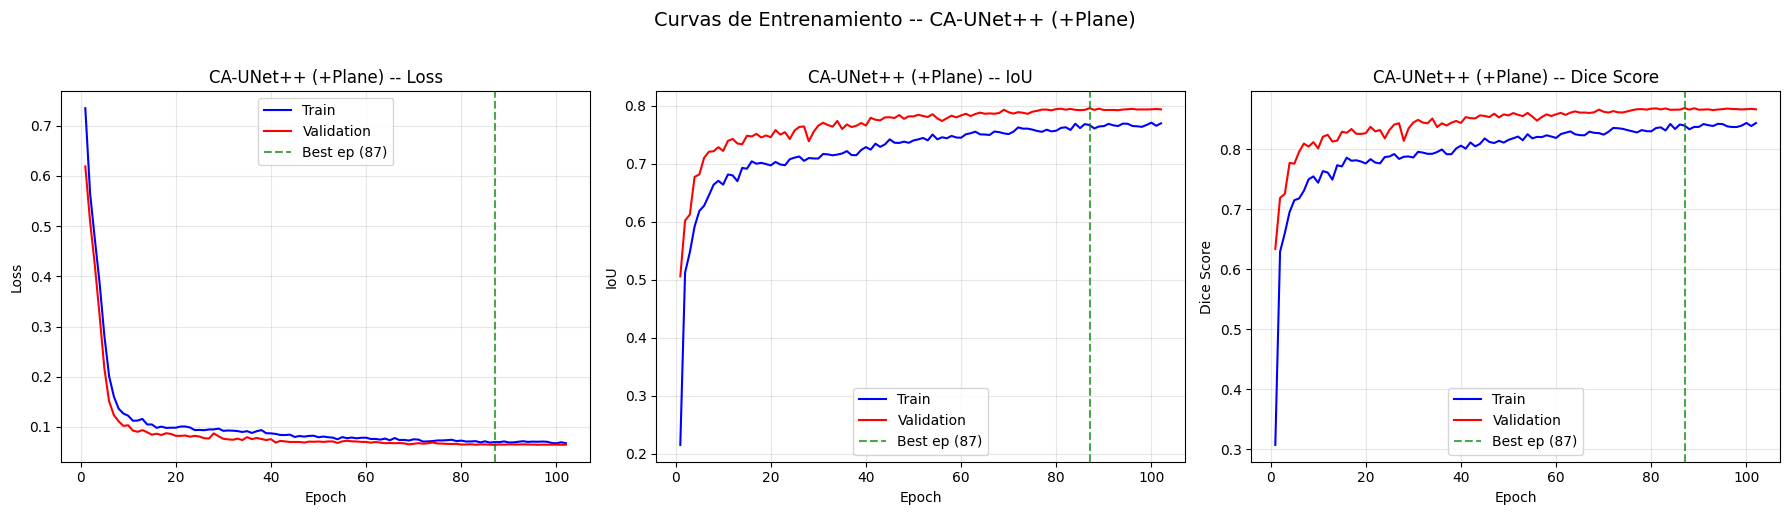


Cargando modelo para visualizacion de predicciones...
  CA-UNet++ (+Plane) cargado (Val Dice: 0.8683)


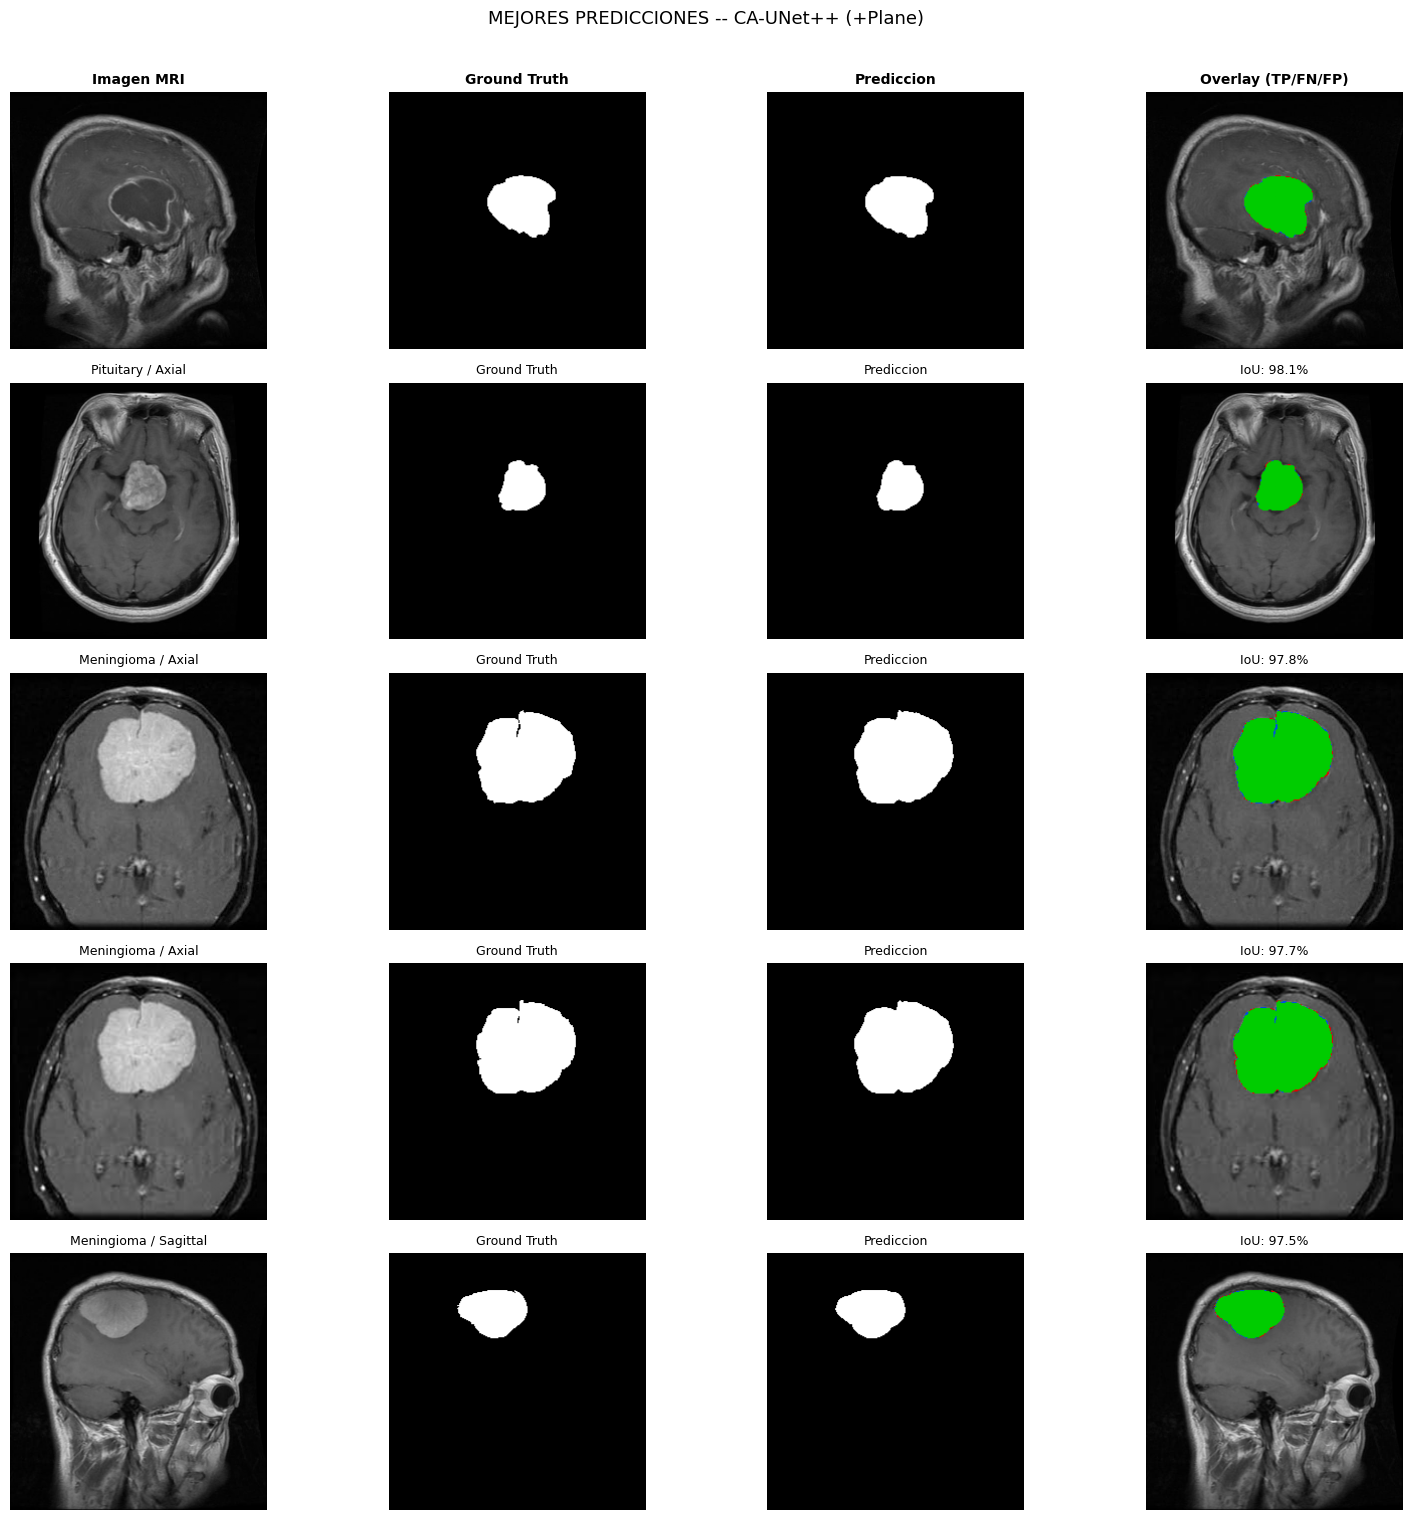

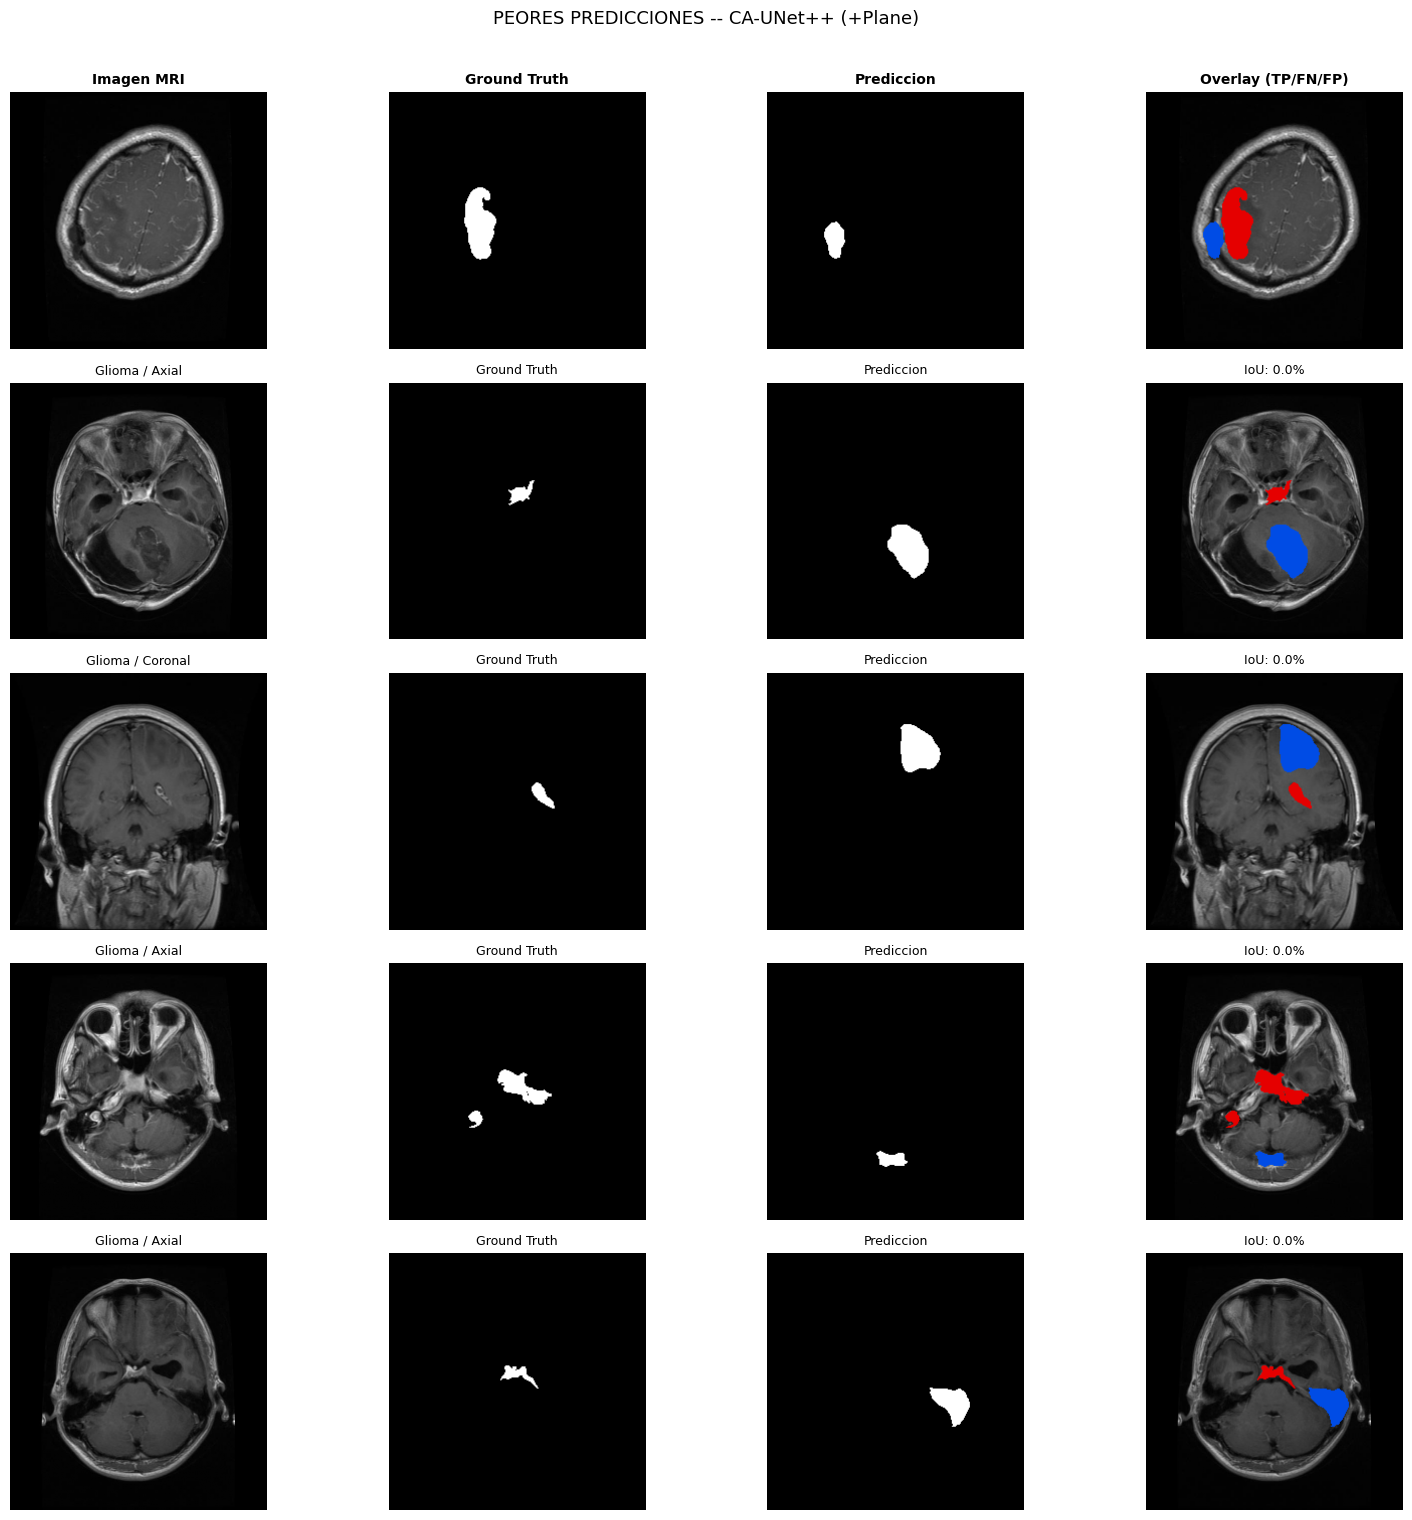

VRAM liberada.


In [35]:
# ============================================================
# VISUALIZACION: CA-UNet++ (+Plane)
# ============================================================

# Corregido: _history_ca_unetplusplus_plusplane
plot_curves(_history_ca_unetplusplus_plusplane, "CA-UNet++ (+Plane)")

print("\nCargando modelo para visualizacion de predicciones...")

# Corregido: _build_ca_unetplusplus_plusplane
_vis_model = load_checkpoint(_build_ca_unetplusplus_plusplane, "CA-UNet++ (+Plane)", base_path, device)

# Corregido: _results_ca_unetplusplus_plusplane
visualize_best_worst(
    _vis_model, _results_ca_unetplusplus_plusplane, df_test, device, "CA-UNet++ (+Plane)", n=5)

del _vis_model; torch.cuda.empty_cache()
print("VRAM liberada.")


## 6.11 Entrenamiento -- Modelo Completo: CA-UNet++ (Full)

El modelo completo combina CBAM y Plane Conditioning, atacando de forma simultanea el Gap 1 (glioma) y el Gap 2 (degradacion axial). Representa la propuesta final del trabajo.

In [36]:
# ============================================================
# ENTRENAMIENTO: CA-UNet++ (Full)
# ============================================================

_name  = "CA-UNet++ (Full)"
# Corregido: _build_ca_unetplusplus_full
_build_ca_unetplusplus_full = lambda: CAUNetPlusPlus(use_cbam=True, use_plane=True)

if already_trained(_name, base_path):
    print(f"\n  {_name} ya entrenado. Cargando desde disco...")
    # Corregido: nombres de variables con guiones bajos
    _history_ca_unetplusplus_full, _summary_ca_unetplusplus_full, _results_ca_unetplusplus_full = load_results(_name, base_path)
else:
    _model = _build_ca_unetplusplus_full()
    _model, _history_ca_unetplusplus_full = train_model(
        _model, _name, train_loader, val_loader, device)
    _results_ca_unetplusplus_full, _summary_ca_unetplusplus_full = save_results(
        _name, _model, _history_ca_unetplusplus_full, test_loader, device, base_path)
    del _model; torch.cuda.empty_cache()
    print(f"  VRAM liberada.")

# Acumular para tabla de ablacion
ablation_summaries = globals().get("ablation_summaries", {})
ablation_histories = globals().get("ablation_histories", {})
ablation_results   = globals().get("ablation_results",   {})

# Corregido: asignación usando las nuevas variables
ablation_summaries[_name] = _summary_ca_unetplusplus_full
ablation_histories[_name] = _history_ca_unetplusplus_full
ablation_results[_name]   = _results_ca_unetplusplus_full

print(f"\n {_name} completado.")



  ENTRENAMIENTO: CA-UNet++ (Full)
  Params totales:      26,711,043
  Params trainables:   26,711,043
  Tamano modelo:          101.9 MB
  Ep   1/150 | Tr Loss:0.5680 IoU:0.3669 Dice:0.4741 | Vl Loss:0.4520 IoU:0.5117 Dice:0.6440 | LR:1.0e-04 | 109.1s * BEST
  Ep   2/150 | Tr Loss:0.3981 IoU:0.5376 Dice:0.6502 | Vl Loss:0.3135 IoU:0.6453 Dice:0.7490 | LR:1.0e-04 | 107.0s * BEST
  Ep   3/150 | Tr Loss:0.2756 IoU:0.5922 Dice:0.6914 | Vl Loss:0.2021 IoU:0.6815 Dice:0.7788 | LR:1.0e-04 | 105.2s * BEST
  Ep   4/150 | Tr Loss:0.1934 IoU:0.6247 Dice:0.7170 | Vl Loss:0.1595 IoU:0.6830 Dice:0.7688 | LR:1.0e-04 | 105.1s (pat: 1/15)
  Ep   5/150 | Tr Loss:0.1578 IoU:0.6372 Dice:0.7253 | Vl Loss:0.1238 IoU:0.7130 Dice:0.8001 | LR:1.0e-04 | 105.5s * BEST
  Ep   6/150 | Tr Loss:0.1384 IoU:0.6548 Dice:0.7400 | Vl Loss:0.1151 IoU:0.7081 Dice:0.7882 | LR:1.0e-04 | 105.9s (pat: 1/15)
  Ep   7/150 | Tr Loss:0.1246 IoU:0.6701 Dice:0.7548 | Vl Loss:0.1089 IoU:0.7021 Dice:0.7898 | LR:1.0e-04 | 104.9s (pat:

### 6.11.1 Curvas de Entrenamiento y Predicciones: Modelo Completo: CA-UNet++ (Full)

Se visualizan las curvas de convergencia y las mejores/peores predicciones del modelo sobre el set de test, cargando el checkpoint desde disco.

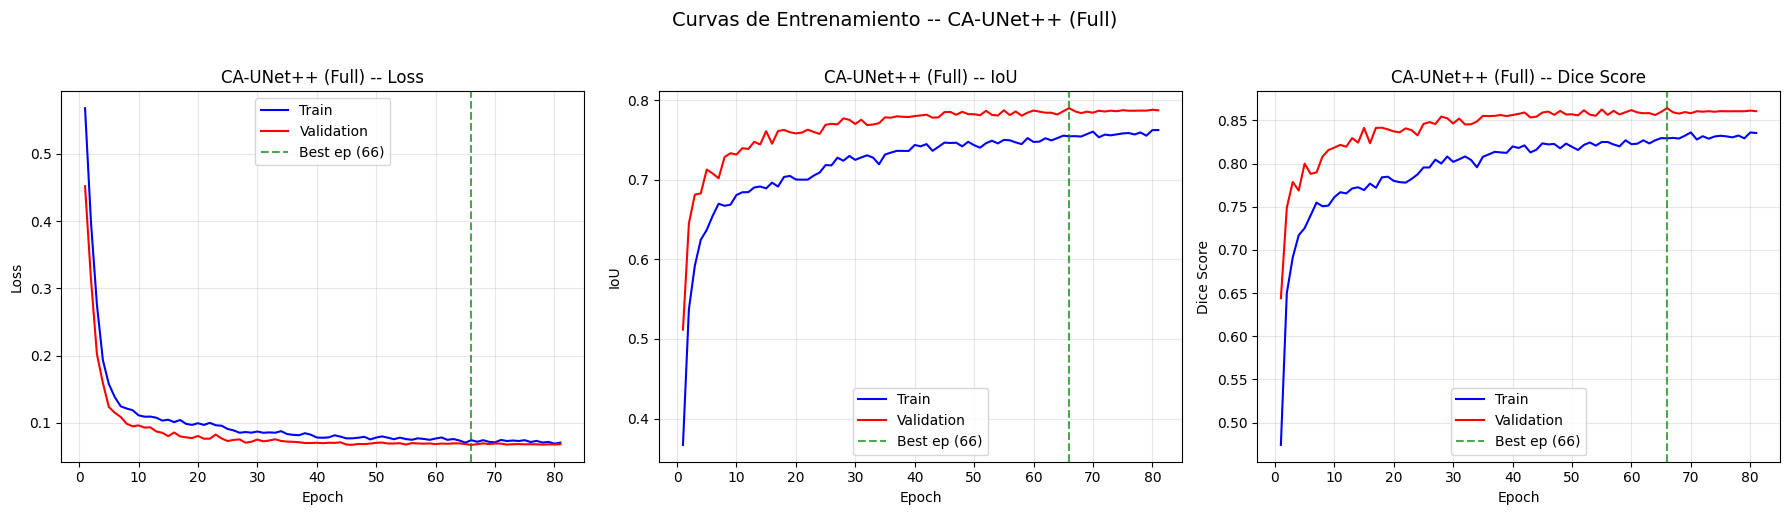


Cargando modelo para visualizacion de predicciones...
  CA-UNet++ (Full) cargado (Val Dice: 0.8643)


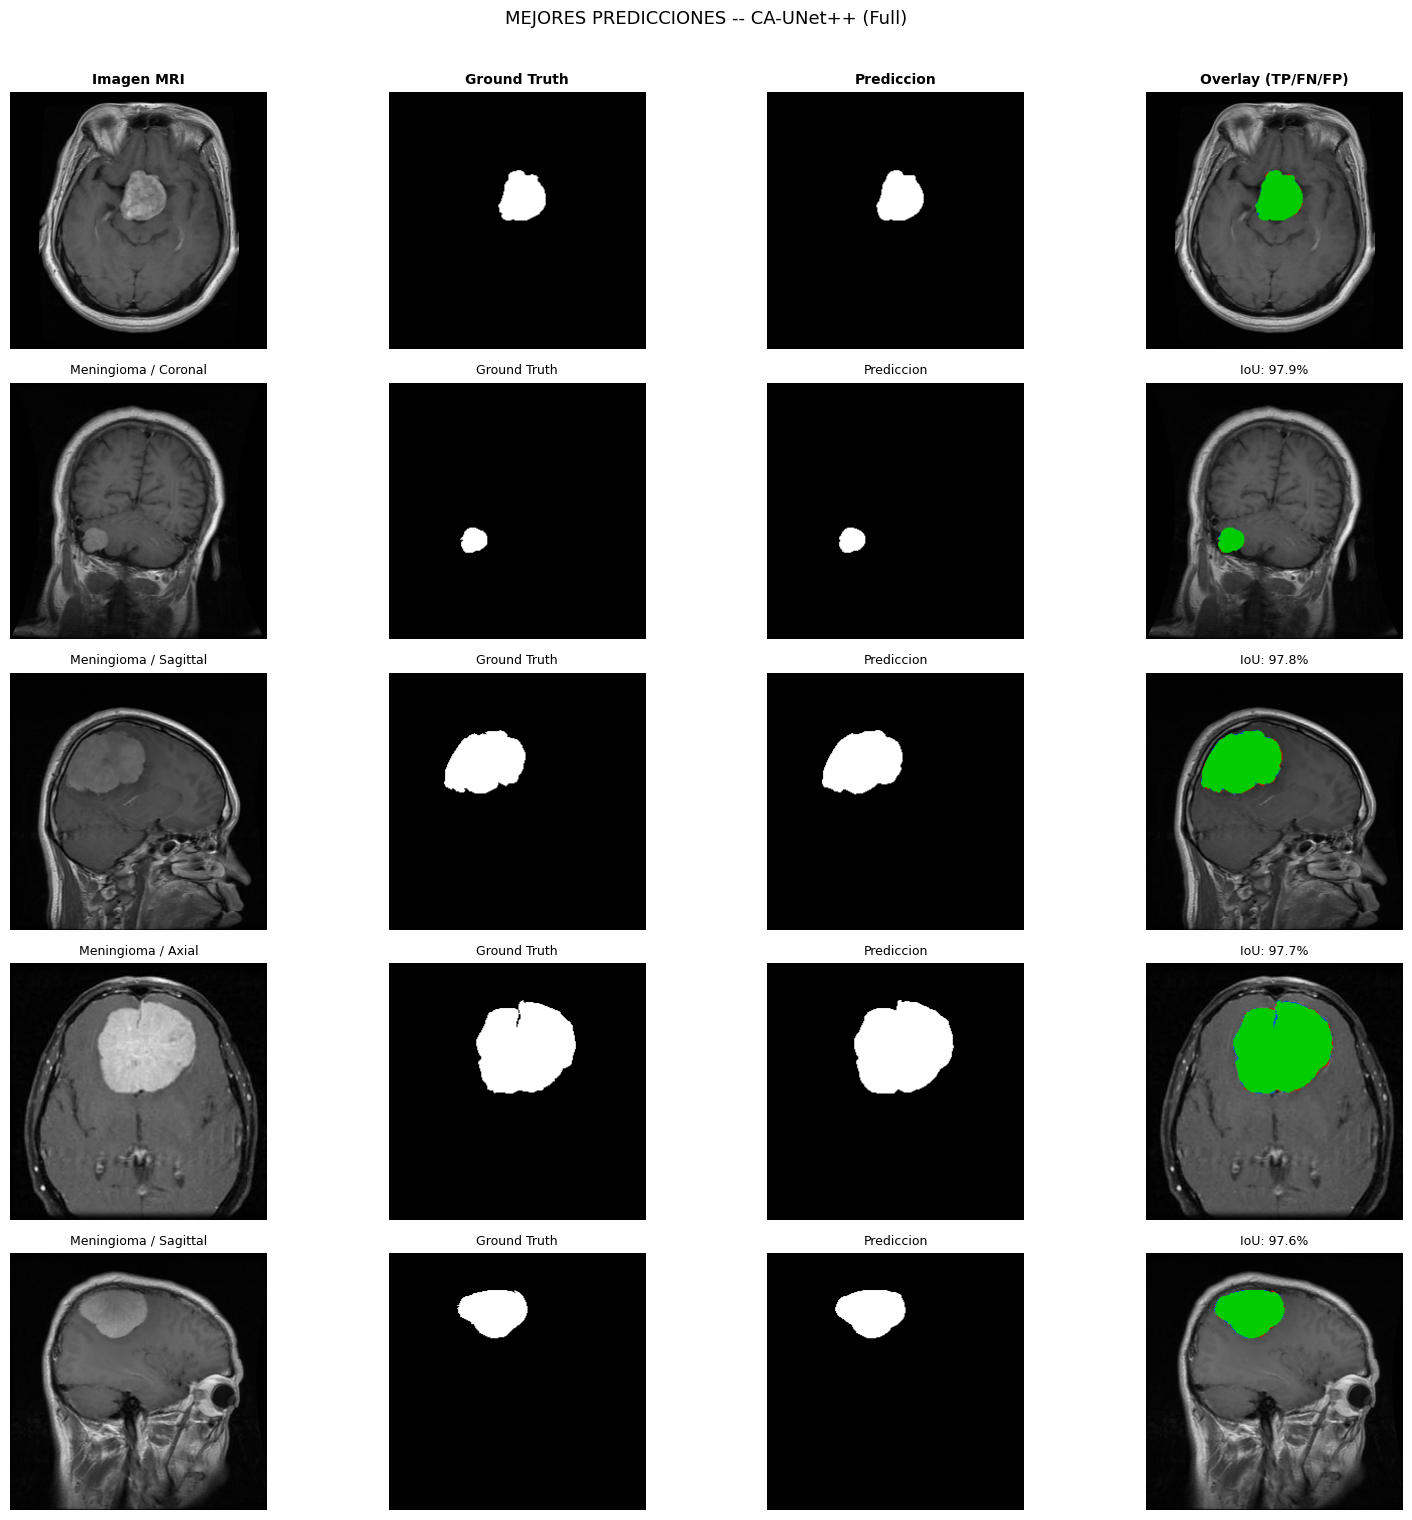

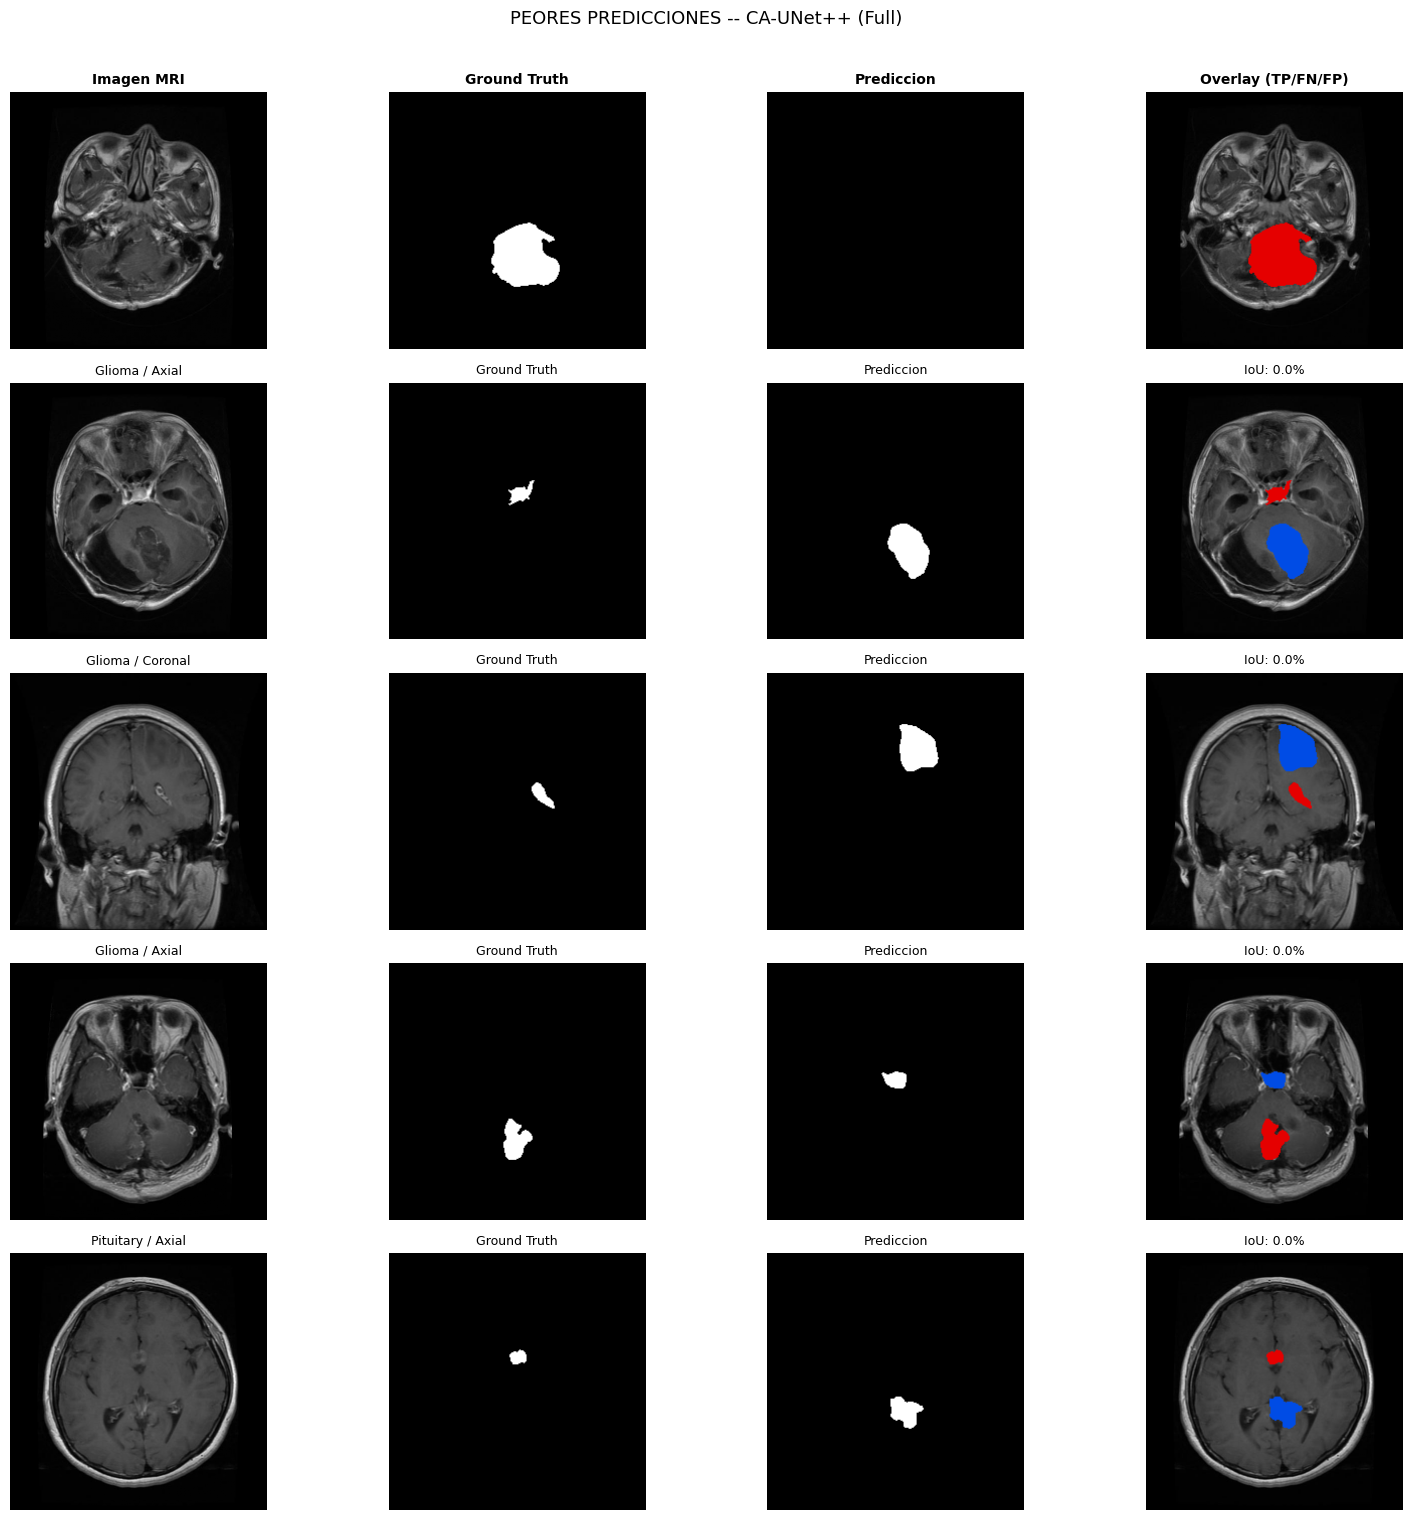

VRAM liberada.


In [37]:
# ============================================================
# VISUALIZACION: CA-UNet++ (Full)
# ============================================================

# Corregido: _history_ca_unetplusplus_full
plot_curves(_history_ca_unetplusplus_full, "CA-UNet++ (Full)")

print("\nCargando modelo para visualizacion de predicciones...")

# Corregido: _build_ca_unetplusplus_full
_vis_model = load_checkpoint(_build_ca_unetplusplus_full, "CA-UNet++ (Full)", base_path, device)

# Corregido: _results_ca_unetplusplus_full
visualize_best_worst(
    _vis_model, _results_ca_unetplusplus_full, df_test, device, "CA-UNet++ (Full)", n=5)

del _vis_model; torch.cuda.empty_cache()
print("VRAM liberada.")


## 6.12 Verificacion del Estado del Estudio de Ablacion

Se verifica que las tres variantes estan entrenadas y los resultados cargados en memoria antes de proceder al analisis comparativo.

In [38]:
# ============================================================
# 9. VERIFICACION ESTADO DE LA ABLACION
# ============================================================

ABLATION_MODELS = [
    ("CA-UNet++ (+CBAM)",  lambda: CAUNetPlusPlus(use_cbam=True,  use_plane=False)),
    ("CA-UNet++ (+Plane)", lambda: CAUNetPlusPlus(use_cbam=False, use_plane=True)),
    ("CA-UNet++ (Full)",   lambda: CAUNetPlusPlus(use_cbam=True,  use_plane=True)),
]

print("=" * 65)
print("  ESTADO DEL ESTUDIO DE ABLACION")
print("=" * 65)

for model_name, _ in ABLATION_MODELS:
    trained   = already_trained(model_name, base_path)
    in_memory = model_name in ablation_summaries
    status    = "Completo" if (trained and in_memory) else "Pendiente"
    print(f"   {status} -- {model_name}")

all_complete = all(already_trained(n, base_path) for n, _ in ABLATION_MODELS)

if all_complete:
    # Asegurar que todo esta en memoria aunque se cargue en una sesion nueva
    if not ablation_summaries:
        print("\n  Cargando resultados desde disco...")
        for model_name, _ in ABLATION_MODELS:
            h, s, r = load_results(model_name, base_path)
            ablation_summaries[model_name] = s
            ablation_histories[model_name] = h
            ablation_results[model_name]   = r
    print(f"\n  Las 3 variantes entrenadas. Listo para analisis comparativo.")
else:
    pending = [n for n, _ in ABLATION_MODELS if not already_trained(n, base_path)]
    print(f"\n  Pendientes: {pending}")


  ESTADO DEL ESTUDIO DE ABLACION
   Pendiente -- CA-UNet++ (+CBAM)
   Pendiente -- CA-UNet++ (+Plane)
   Pendiente -- CA-UNet++ (Full)

  Pendientes: ['CA-UNet++ (+CBAM)', 'CA-UNet++ (+Plane)', 'CA-UNet++ (Full)']


## 6.13 Estudio de Ablacion y Tabla Comparativa Final

Se consolidan los resultados de las tres variantes junto con el baseline UNet++ (Fase 5) para construir la tabla de ablacion completa. Esta tabla cuantifica la contribucion independiente de cada modulo y es el elemento central de la contribucion experimental del paper.

In [39]:
# ============================================================
# 10. TABLA DE ABLACION Y COMPARATIVA FINAL
# ============================================================

# Cargar baseline UNet++ de la Fase 5
baseline_path = os.path.join(base_path, "results", "unetplusplus_summary.json")
with open(baseline_path) as f:
    baseline_summ = json.load(f)

rows_ablation = [
    ("UNet++ (Baseline)",   "N", "N", baseline_summ),
    ("CA-UNet++ (+CBAM)",   "S", "N", ablation_summaries.get("CA-UNet++ (+CBAM)", {})),
    ("CA-UNet++ (+Plane)",  "N", "S", ablation_summaries.get("CA-UNet++ (+Plane)", {})),
    ("CA-UNet++ (Full) *",  "S", "S", ablation_summaries.get("CA-UNet++ (Full)", {})),
]

print("=" * 95)
print("  ESTUDIO DE ABLACION -- CA-UNet++ sobre BRISC 2025")
print("=" * 95)
print(f"  {'Variante':<26} {'CBAM':^5} {'Plane':^5} "
      f"{'W-mIoU':>8} {'Glioma':>8} {'Mening.':>8} "
      f"{'Pituit.':>8} {'Axial':>8} {'Coronal':>8} {'Sagitt.':>8}")
print("  " + "-" * 93)

for name, cbam, plane, s in rows_ablation:
    if not s: continue
    wm  = s.get("weighted_miou", 0) * 100
    ti  = s.get("tumor_iou", {})
    pi  = s.get("plane_iou", {})
    gl  = ti.get("Glioma",     0) * 100
    me  = ti.get("Meningioma", 0) * 100
    pit = ti.get("Pituitary",  0) * 100
    ax  = pi.get("Axial",      0) * 100
    co  = pi.get("Coronal",    0) * 100
    sa  = pi.get("Sagittal",   0) * 100
    flag = "  <- META SUPERADA" if wm > 80.6 else ""
    print(f"  {name:<26} {cbam:^5} {plane:^5} "
          f"{wm:>7.2f}% {gl:>7.2f}% {me:>7.2f}% "
          f"{pit:>7.2f}% {ax:>7.2f}% {co:>7.2f}% {sa:>7.2f}%{flag}")

print("  " + "-" * 93)
print("  Referencia: SaberNet (BRISC) -- W-mIoU: 80.6%")

# -- Brecha axial-sagittal -----------------------------------
print("\n\n" + "=" * 62)
print("  BRECHA AXIAL-SAGITTAL por variante")
print("=" * 62)
print(f"  {'Variante':<26} {'Axial':>8} {'Coronal':>8} {'Sagitt.':>8} {'Brecha A-S':>12}")
print("  " + "-" * 66)
for name, _, _, s in rows_ablation:
    if not s: continue
    pi  = s.get("plane_iou", {})
    ax  = pi.get("Axial",    0) * 100
    co  = pi.get("Coronal",  0) * 100
    sa  = pi.get("Sagittal", 0) * 100
    gap = sa - ax
    print(f"  {name:<26} {ax:>7.2f}% {co:>7.2f}% {sa:>7.2f}% {gap:>10.2f} pp")
print("  Nota: reduccion de brecha indica mejor generalizacion entre planos.")


  ESTUDIO DE ABLACION -- CA-UNet++ sobre BRISC 2025
  Variante                   CBAM  Plane   W-mIoU   Glioma  Mening.  Pituit.    Axial  Coronal  Sagitt.
  ---------------------------------------------------------------------------------------------
  UNet++ (Baseline)            N     N     79.90%   67.54%   90.39%   79.66%   78.40%   80.17%   81.64%
  CA-UNet++ (+CBAM)            S     N     80.33%   69.27%   90.26%   79.56%   79.00%   80.20%   82.25%
  CA-UNet++ (+Plane)           N     S     80.50%   69.12%   90.34%   80.09%   78.64%   80.95%   82.53%
  CA-UNet++ (Full) *           S     S     79.97%   68.06%   90.44%   79.36%   78.41%   80.31%   81.72%
  ---------------------------------------------------------------------------------------------
  Referencia: SaberNet (BRISC) -- W-mIoU: 80.6%


  BRECHA AXIAL-SAGITTAL por variante
  Variante                      Axial  Coronal  Sagitt.   Brecha A-S
  ------------------------------------------------------------------
  UNet++ (B

## 6.14 Analisis de Significancia Estadistica

Para que la mejora del modelo propuesto sobre el baseline sea reportable en un paper, no basta con que el Weighted mIoU agregado sea mayor: se requiere verificar que la diferencia a nivel de imagen individual es estadisticamente significativa.

Se aplica el **test de Wilcoxon de rangos con signos** (test pareado no parametrico) comparando el IoU por imagen entre cada variante y el baseline UNet++. Se utiliza este test porque: (i) las comparaciones son pareadas -- ambos modelos se evaluan sobre las mismas 860 imagenes de test -- y (ii) la distribucion del IoU por imagen es asimetrica (right-skewed), violando el supuesto de normalidad requerido por el t-test.

La hipotesis nula H0 establece que la distribucion del IoU del modelo propuesto es identica a la del baseline. Se utiliza un nivel de significancia alpha = 0.05 con correccion de Bonferroni para comparaciones multiples (3 variantes).

In [40]:
# ============================================================
# 11. ANALISIS DE SIGNIFICANCIA ESTADISTICA
# ============================================================

# Cargar resultados por imagen del baseline UNet++ (Fase 5)
baseline_results_path = os.path.join(
    base_path, "results", "unetplusplus_test_results.csv")
df_baseline = pd.read_csv(baseline_results_path)
df_baseline = df_baseline.sort_values("filename").reset_index(drop=True)

# Correccion de Bonferroni: 3 comparaciones
alpha       = 0.05
alpha_bonf  = alpha / 3

print("=" * 75)
print("  ANALISIS DE SIGNIFICANCIA ESTADISTICA")
print("  Test de Wilcoxon pareado (IoU por imagen) vs. UNet++ (Baseline)")
print("=" * 75)
print(f"  Alpha: {alpha}  |  Alpha Bonferroni (3 comp.): {alpha_bonf:.4f}\n")
print(f"  {'Variante':<26} {'W-mIoU':>8} {'Delta':>8} {'Wilcoxon W':>12} "
      f"{'p-valor':>10} {'p (Bonf.)':>11} {'Significativo':>14}")
print("  " + "-" * 93)

stat_results = {}

for model_name, _, s in [
    ("CA-UNet++ (+CBAM)",  None, ablation_summaries.get("CA-UNet++ (+CBAM)",  {})),
    ("CA-UNet++ (+Plane)", None, ablation_summaries.get("CA-UNet++ (+Plane)", {})),
    ("CA-UNet++ (Full)",   None, ablation_summaries.get("CA-UNet++ (Full)",   {})),
]:
    if not s or model_name not in ablation_results: continue

    df_prop = ablation_results[model_name].sort_values("filename").reset_index(drop=True)

    # Alinear por filename (mismo orden garantizado por sort)
    merged = df_baseline[["filename","iou"]].merge(
        df_prop[["filename","iou"]], on="filename", suffixes=("_base","_prop"))

    iou_base = merged["iou_base"].values
    iou_prop = merged["iou_prop"].values

    # Test de Wilcoxon pareado (H0: distribuciones identicas)
    w_stat, p_val = stats.wilcoxon(iou_prop, iou_base, alternative="greater")
    p_bonf        = min(p_val * 3, 1.0)  # Correccion de Bonferroni

    wm_base = baseline_summ.get("weighted_miou", 0) * 100
    wm_prop = s.get("weighted_miou", 0) * 100
    delta   = wm_prop - wm_base
    sig     = "Si **" if p_bonf < alpha_bonf else "No"

    stat_results[model_name] = {
        "w_stat": w_stat, "p_val": p_val, "p_bonf": p_bonf,
        "delta": delta, "significant": p_bonf < alpha_bonf
    }

    print(f"  {model_name:<26} {wm_prop:>7.2f}% {delta:>+7.2f}pp "
          f"{w_stat:>12.1f} {p_val:>10.4f} {p_bonf:>11.4f} {sig:>14}")

print("  " + "-" * 93)
print("  ** Significativo con correccion de Bonferroni (alpha/3 = {:.4f})".format(alpha_bonf))

# -- Analisis por clase tumoral ------------------------------
print("\n\n  ANALISIS POR TIPO TUMORAL -- test de Wilcoxon pareado")
print("  " + "-" * 70)

best_model = "CA-UNet++ (Full)"
if best_model in ablation_results:
    df_full = ablation_results[best_model].sort_values("filename").reset_index(drop=True)
    merged_t = df_baseline[["filename","tumor_label","iou"]].merge(
        df_full[["filename","iou"]], on="filename", suffixes=("_base","_full"))

    print(f"  {'Tumor':<12} {'IoU Base':>10} {'IoU Full':>10} {'Delta':>8} "
          f"{'p-valor':>10} {'Significativo':>14}")
    print("  " + "-" * 70)

    for tumor in ["Glioma", "Meningioma", "Pituitary"]:
        sub = merged_t[merged_t["tumor_label"] == tumor]
        w, p = stats.wilcoxon(sub["iou_full"].values,
                               sub["iou_base"].values, alternative="greater")
        base_m = sub["iou_base"].mean() * 100
        full_m = sub["iou_full"].mean() * 100
        delta  = full_m - base_m
        sig    = "Si **" if p < alpha else "No"
        print(f"  {tumor:<12} {base_m:>9.2f}% {full_m:>9.2f}% "
              f"{delta:>+7.2f}pp {p:>10.4f} {sig:>14}")


  ANALISIS DE SIGNIFICANCIA ESTADISTICA
  Test de Wilcoxon pareado (IoU por imagen) vs. UNet++ (Baseline)
  Alpha: 0.05  |  Alpha Bonferroni (3 comp.): 0.0167

  Variante                     W-mIoU    Delta   Wilcoxon W    p-valor   p (Bonf.)  Significativo
  ---------------------------------------------------------------------------------------------
  CA-UNet++ (+CBAM)            80.33%   +0.43pp     175872.0     0.8508      1.0000             No
  CA-UNet++ (+Plane)           80.50%   +0.60pp     198565.5     0.0154      0.0463             No
  CA-UNet++ (Full)             79.97%   +0.07pp     177279.0     0.7846      1.0000             No
  ---------------------------------------------------------------------------------------------
  ** Significativo con correccion de Bonferroni (alpha/3 = 0.0167)


  ANALISIS POR TIPO TUMORAL -- test de Wilcoxon pareado
  ----------------------------------------------------------------------
  Tumor          IoU Base   IoU Full    Delta    p-valo

## 6.15 Visualizacion del Estudio de Ablacion

Se genera un panel comparativo de tres graficos que presenta visualmente las contribuciones de cada modulo sobre (i) Weighted mIoU global con la linea de referencia de SaberNet, (ii) mIoU por tipo tumoral y (iii) mIoU por plano anatomico. Este panel esta disenado para su inclusion directa en el paper.

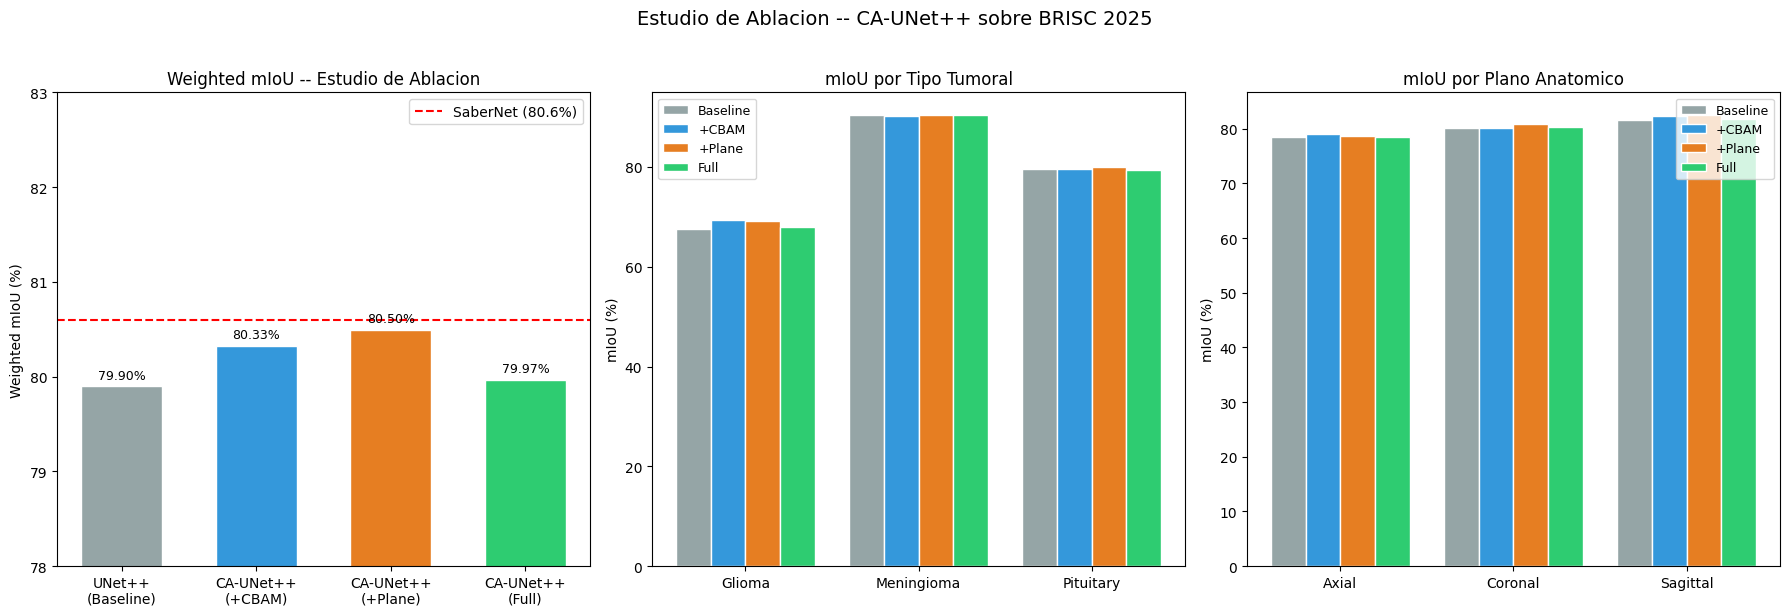

Figura de ablacion guardada.


In [41]:
# ============================================================
# 12. VISUALIZACION DEL ESTUDIO DE ABLACION
# ============================================================

names_plot = ["UNet++\n(Baseline)", "CA-UNet++\n(+CBAM)",
               "CA-UNet++\n(+Plane)", "CA-UNet++\n(Full)"]
summs_plot = [
    baseline_summ,
    ablation_summaries.get("CA-UNet++ (+CBAM)",  {}),
    ablation_summaries.get("CA-UNet++ (+Plane)", {}),
    ablation_summaries.get("CA-UNet++ (Full)",   {}),
]
colors = ["#95A5A6", "#3498DB", "#E67E22", "#2ECC71"]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: Weighted mIoU
w_vals = [s.get("weighted_miou", 0)*100 for s in summs_plot]
bars   = axes[0].bar(names_plot, w_vals, color=colors, edgecolor="white", width=0.6)
axes[0].axhline(80.6, color="red", ls="--", lw=1.5, label="SaberNet (80.6%)")
axes[0].set_title("Weighted mIoU -- Estudio de Ablacion", fontsize=12)
axes[0].set_ylabel("Weighted mIoU (%)")
axes[0].set_ylim(78, 83)
axes[0].legend()
for b, v in zip(bars, w_vals):
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+0.05,
                 f"{v:.2f}%", ha="center", va="bottom", fontsize=9)

# Panel 2: mIoU por tumor
tumors = ["Glioma","Meningioma","Pituitary"]
x, w  = np.arange(len(tumors)), 0.2
for j,(s,c,lbl) in enumerate(zip(summs_plot, colors,
                                  ["Baseline","+CBAM","+Plane","Full"])):
    vals = [s.get("tumor_iou",{}).get(t,0)*100 for t in tumors]
    axes[1].bar(x+j*w, vals, w, label=lbl, color=c, edgecolor="white")
axes[1].set_title("mIoU por Tipo Tumoral", fontsize=12)
axes[1].set_ylabel("mIoU (%)")
axes[1].set_xticks(x+w*1.5); axes[1].set_xticklabels(tumors)
axes[1].legend(fontsize=9)

# Panel 3: mIoU por plano
planes = ["Axial","Coronal","Sagittal"]
x2     = np.arange(len(planes))
for j,(s,c,lbl) in enumerate(zip(summs_plot, colors,
                                  ["Baseline","+CBAM","+Plane","Full"])):
    vals = [s.get("plane_iou",{}).get(p,0)*100 for p in planes]
    axes[2].bar(x2+j*w, vals, w, label=lbl, color=c, edgecolor="white")
axes[2].set_title("mIoU por Plano Anatomico", fontsize=12)
axes[2].set_ylabel("mIoU (%)")
axes[2].set_xticks(x2+w*1.5); axes[2].set_xticklabels(planes)
axes[2].legend(fontsize=9)

plt.suptitle("Estudio de Ablacion -- CA-UNet++ sobre BRISC 2025",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("proposed_ablation_study.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura de ablacion guardada.")


## 6.16 Visualizacion Comparativa: Mejores y Peores Predicciones por Variante

Se visualizan las mejores y peores predicciones de cada variante sobre el set de test, siguiendo el mismo patron del notebook de benchmarks (Fase 5). Cada modelo se carga desde checkpoint y se libera la VRAM despues de cada visualizacion.

  RESULTADOS CONSOLIDADOS EN TEST -- MODELO PROPUESTO
  Variantes evaluadas: ['CA-UNet++ (+CBAM)', 'CA-UNet++ (+Plane)', 'CA-UNet++ (Full)']


─────────────────────────────────────────────────────────────────
  Best/Worst -- CA-UNet++ (+CBAM)
─────────────────────────────────────────────────────────────────
  CA-UNet++ (+CBAM) cargado (Val Dice: 0.8635)


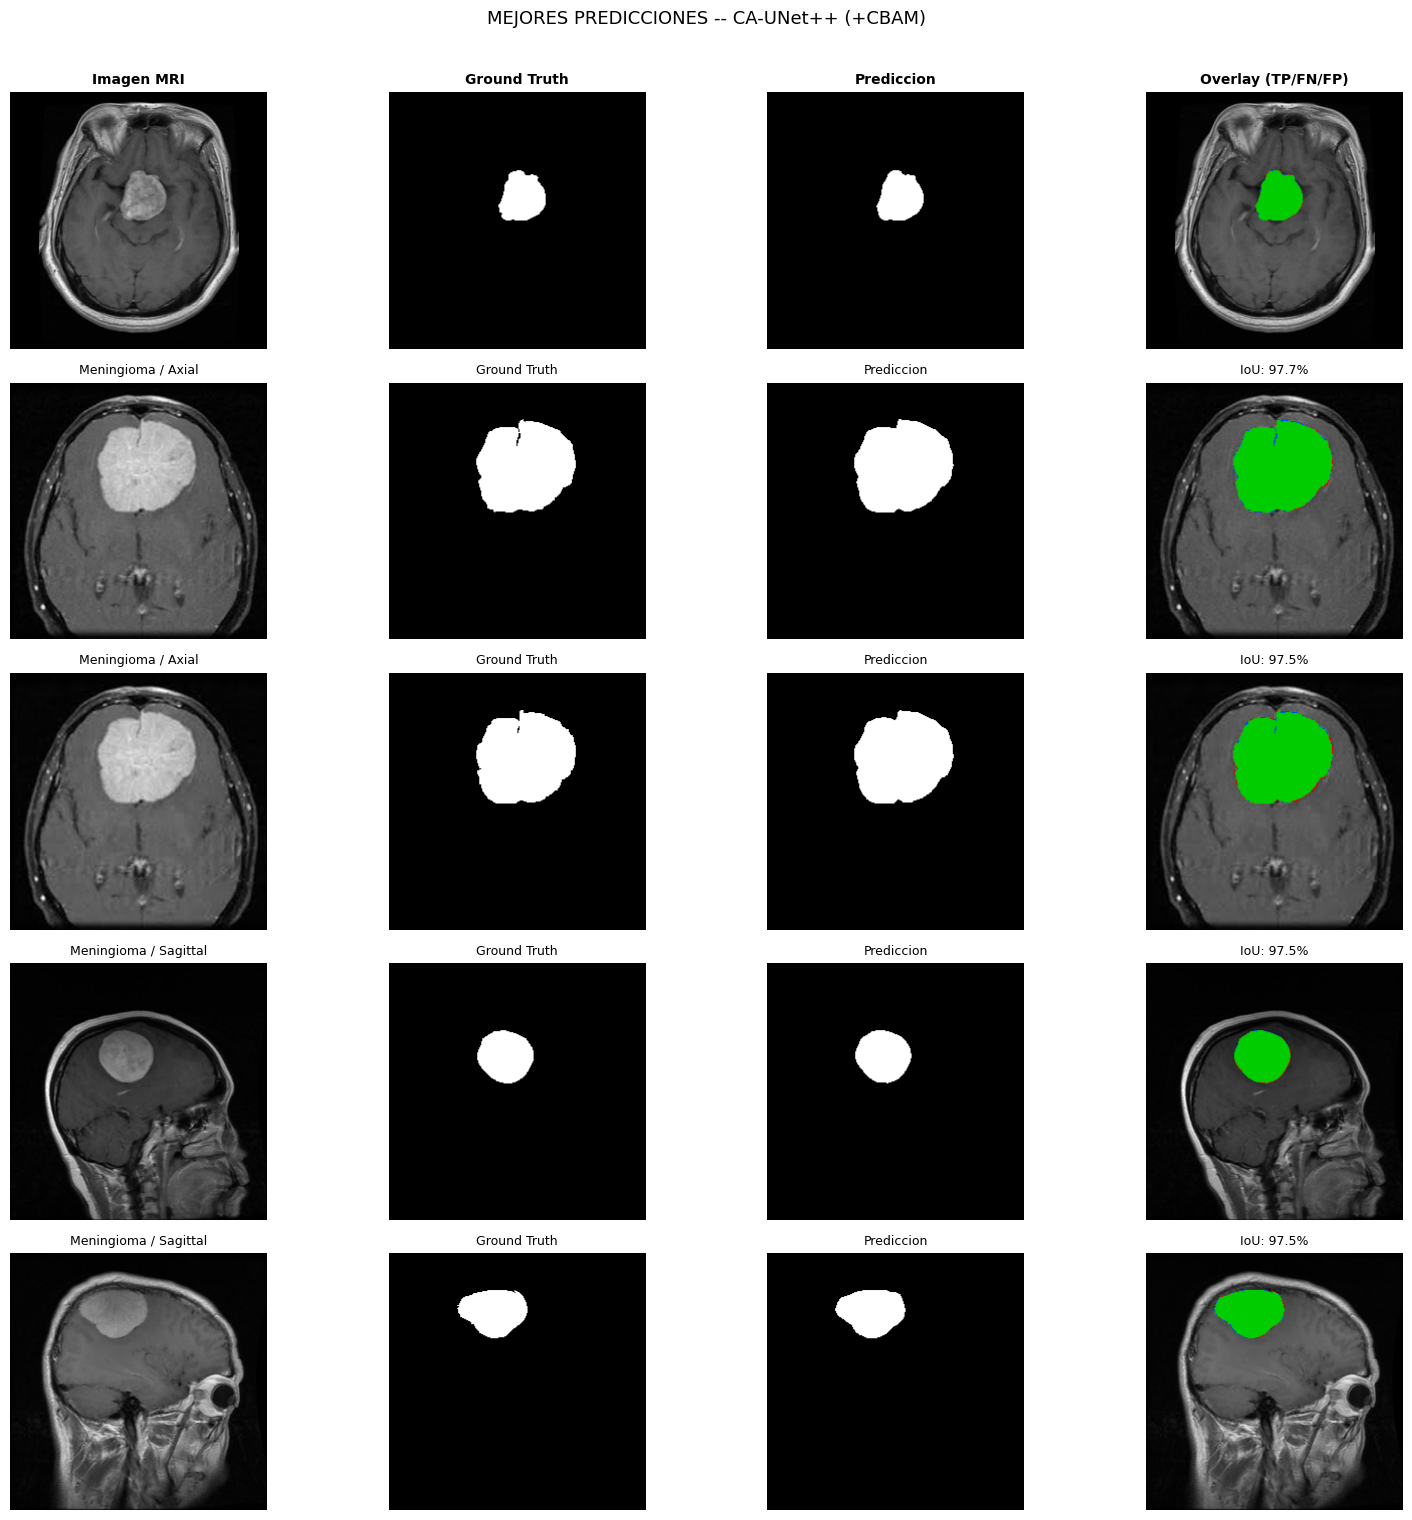

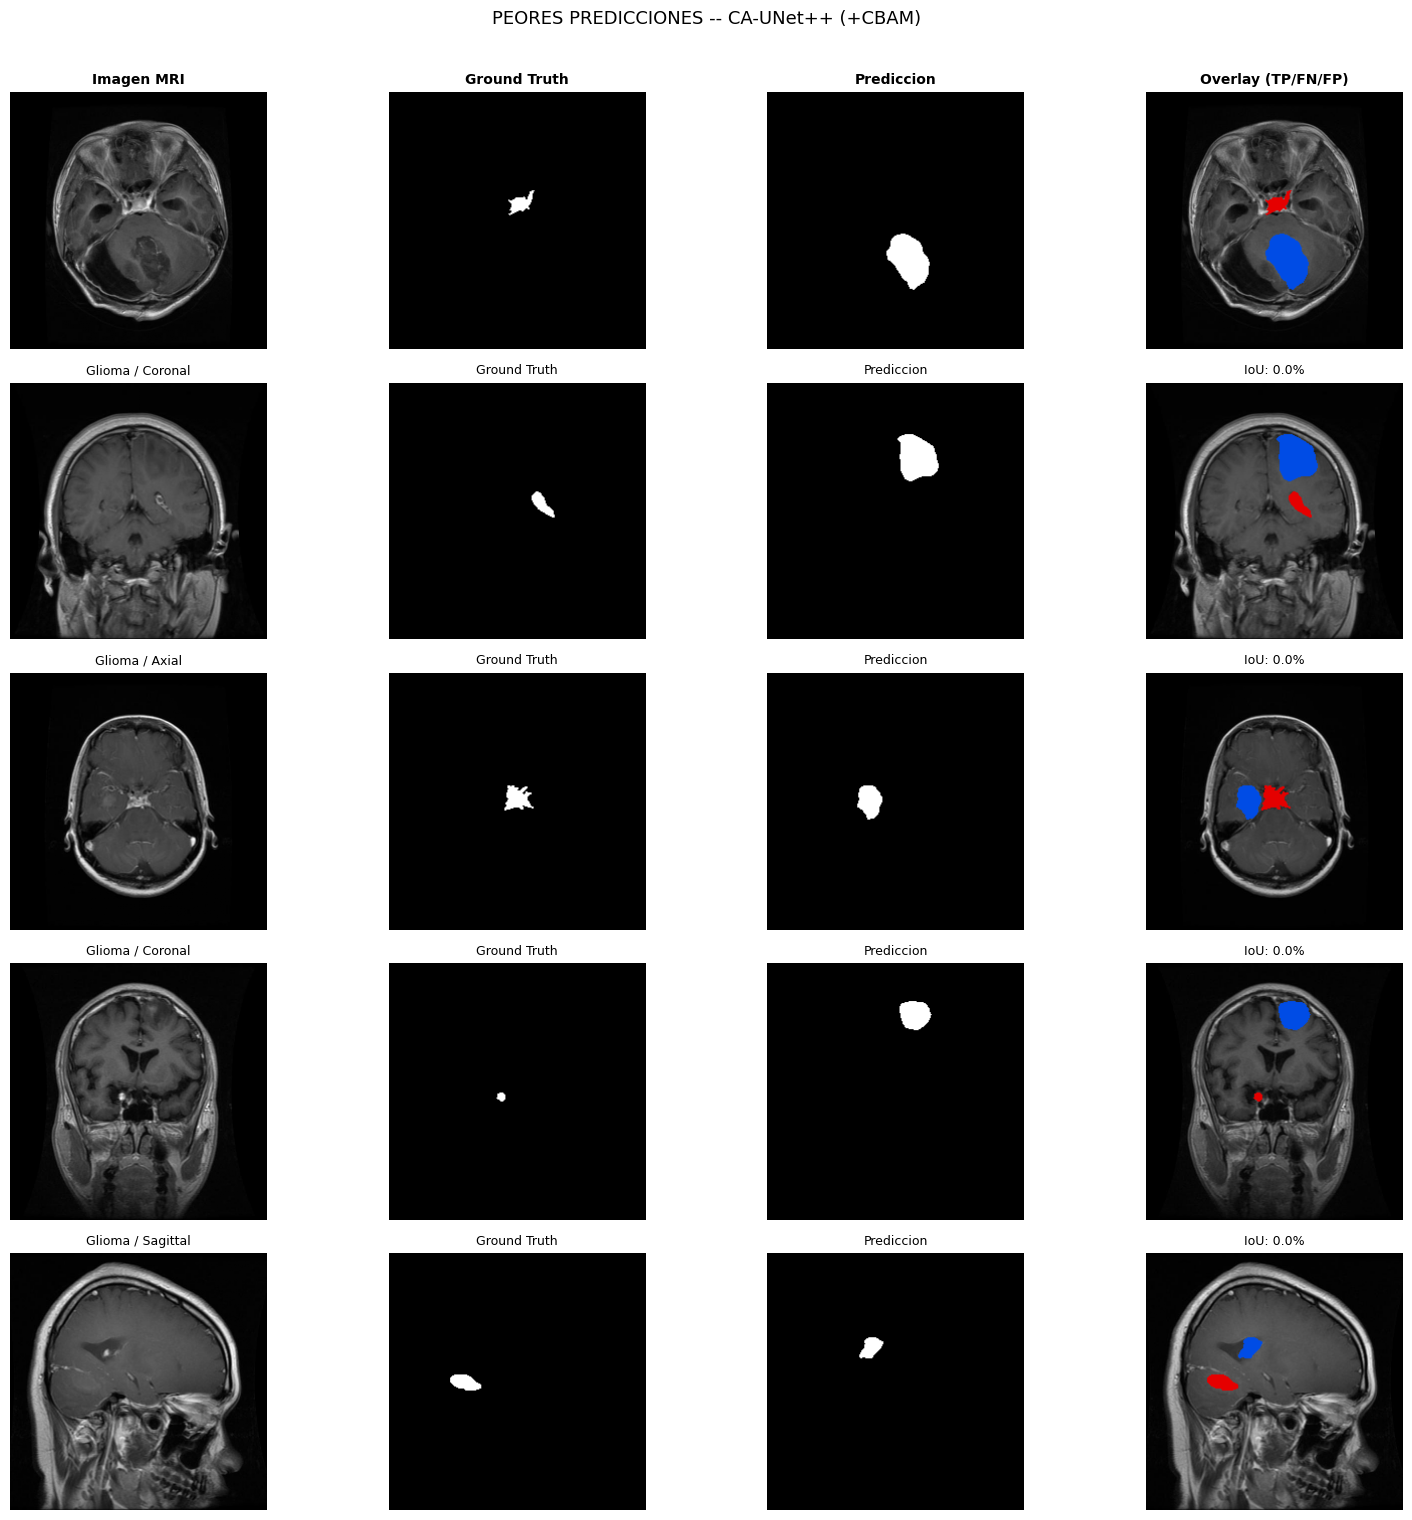


─────────────────────────────────────────────────────────────────
  Best/Worst -- CA-UNet++ (+Plane)
─────────────────────────────────────────────────────────────────
  CA-UNet++ (+Plane) cargado (Val Dice: 0.8683)


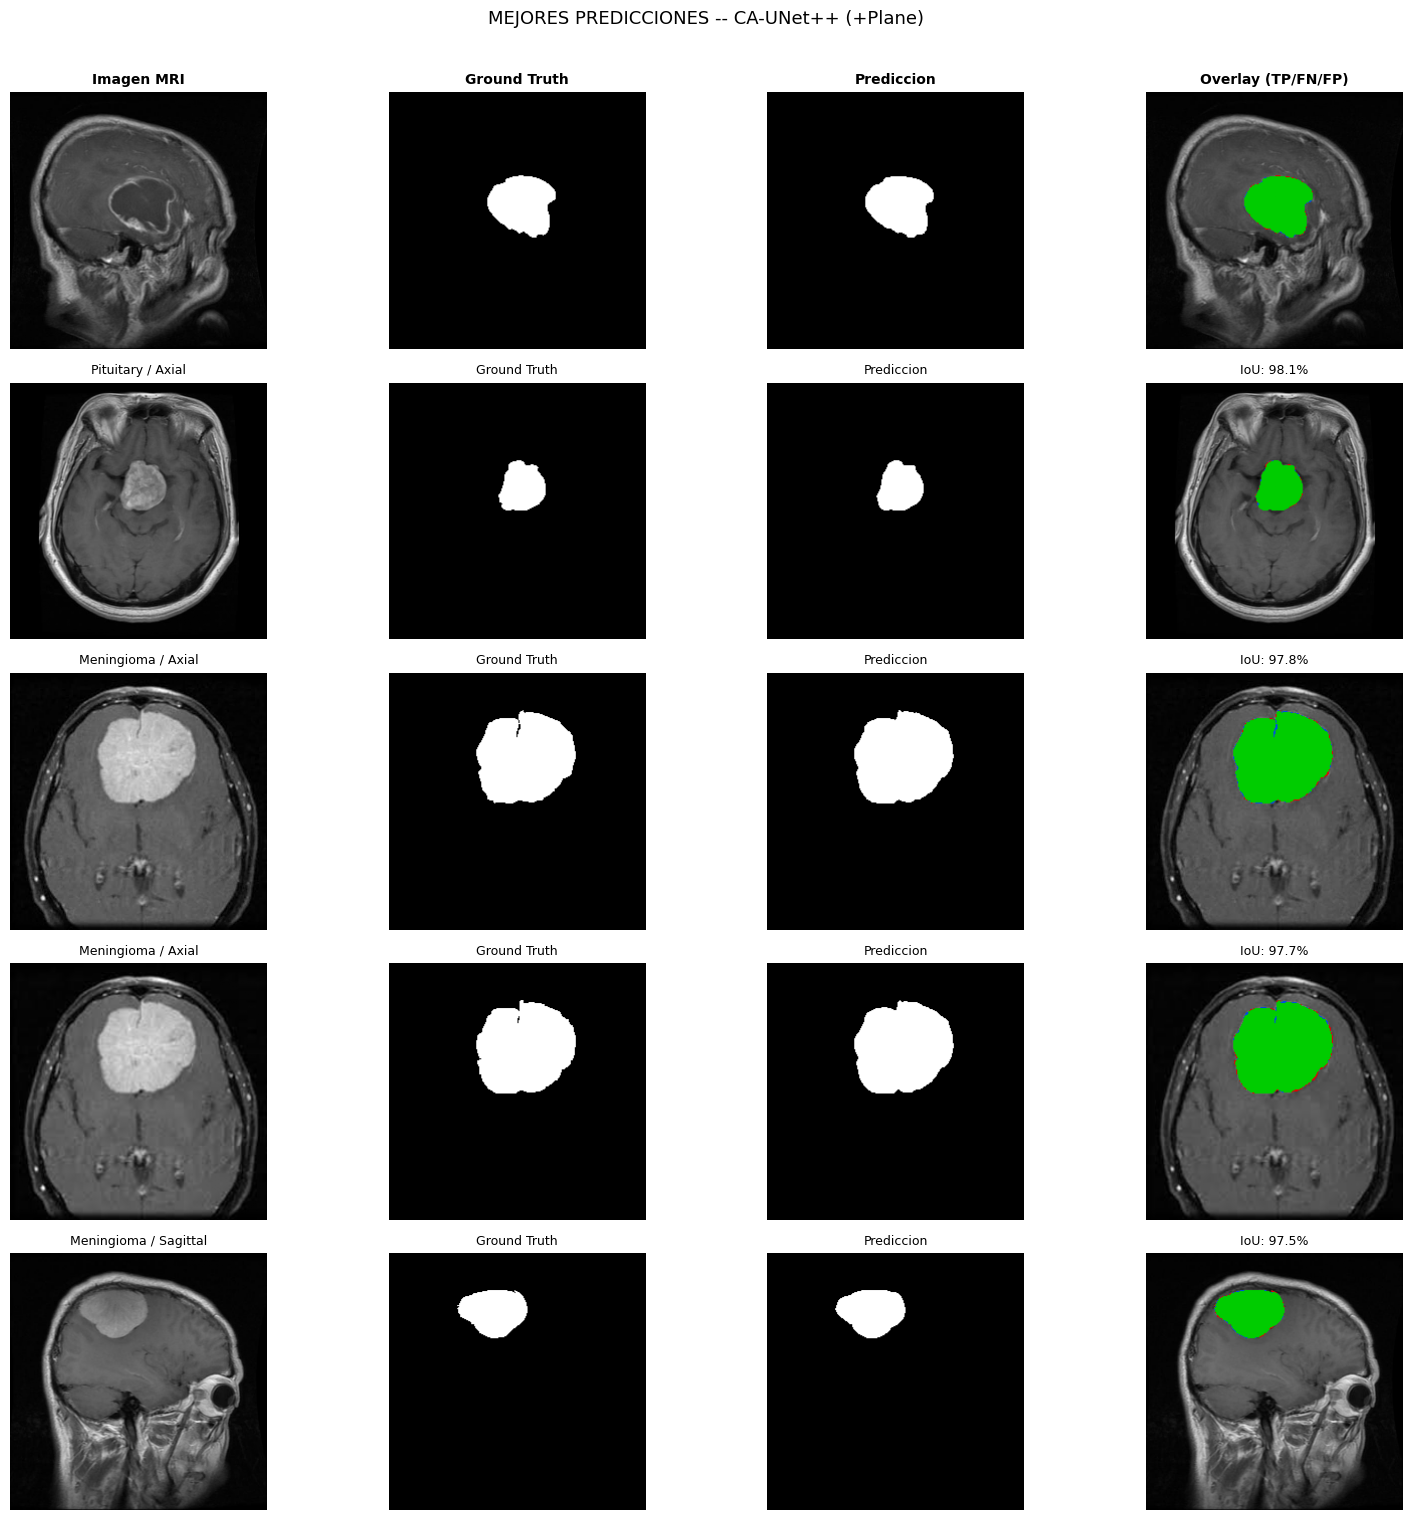

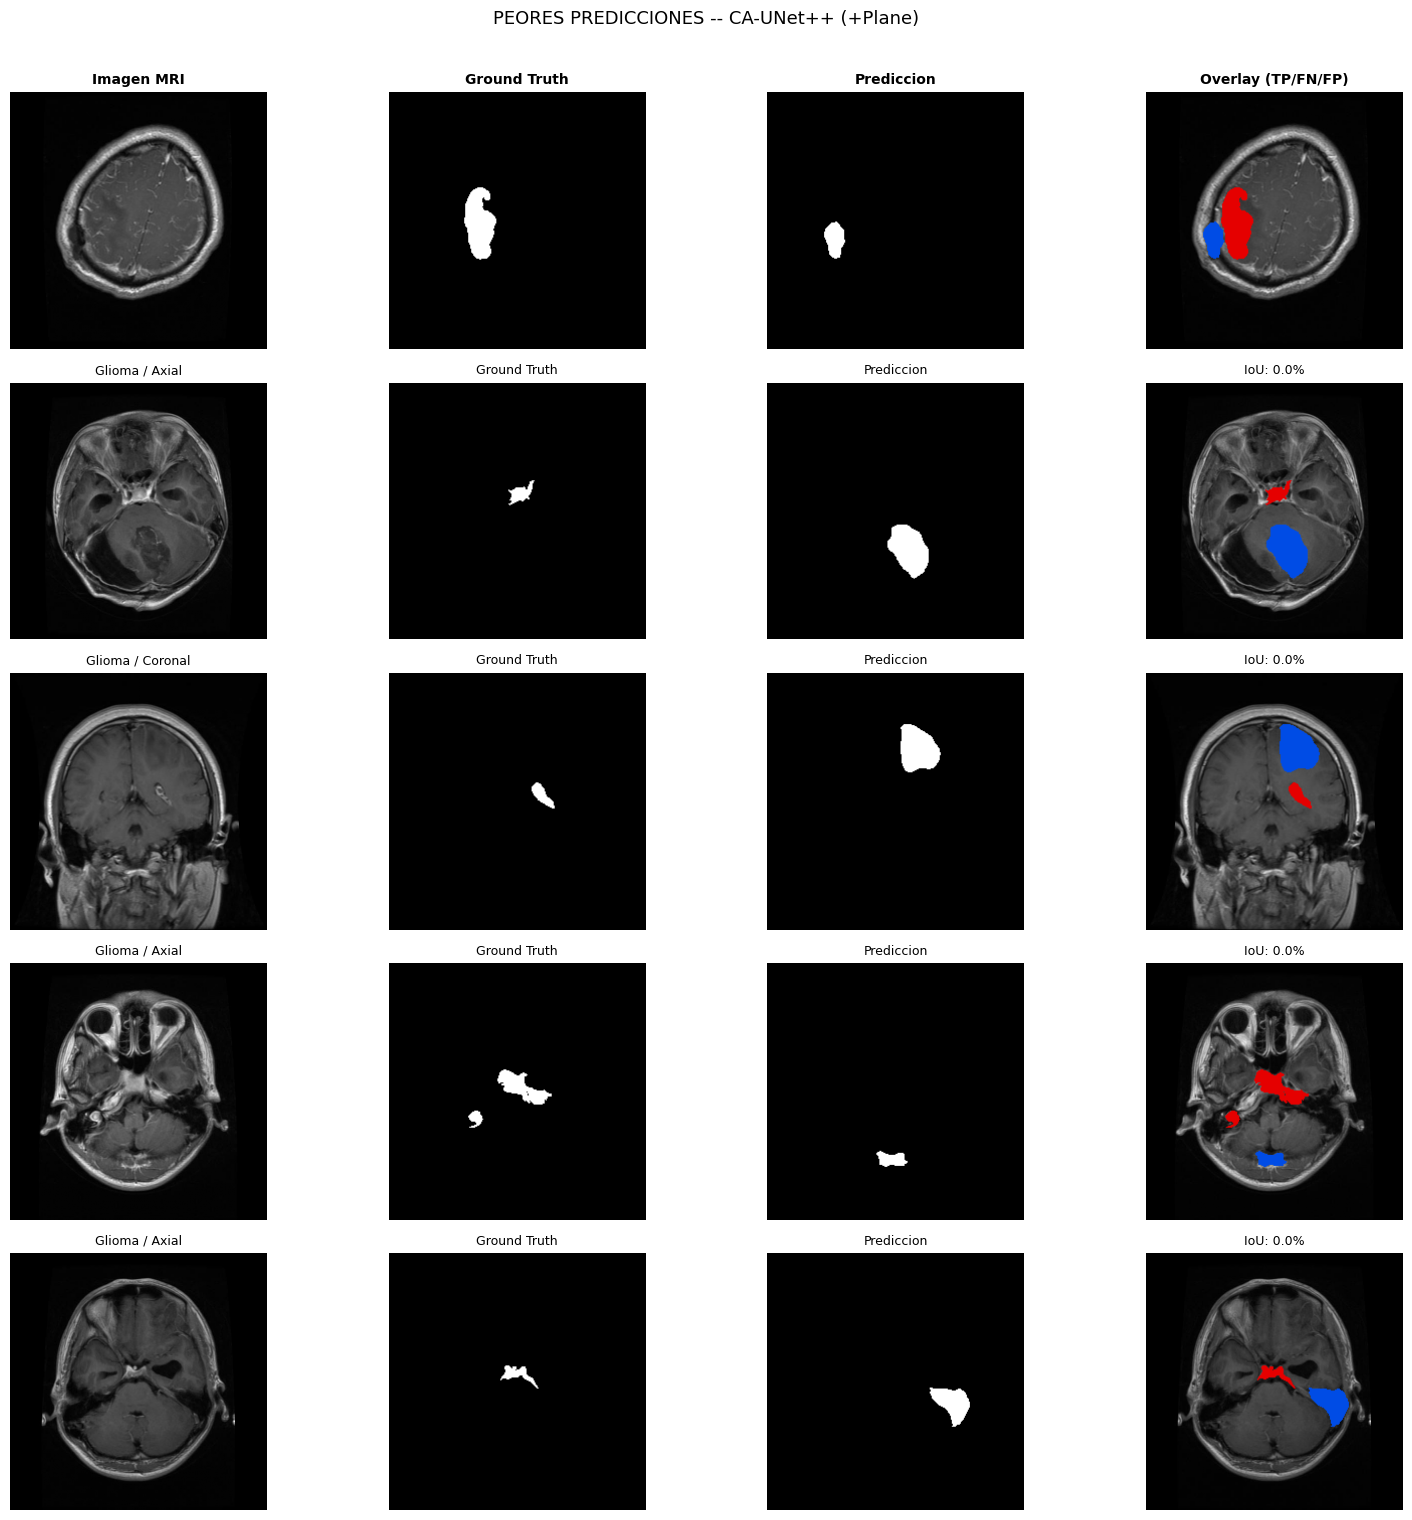


─────────────────────────────────────────────────────────────────
  Best/Worst -- CA-UNet++ (Full)
─────────────────────────────────────────────────────────────────
  CA-UNet++ (Full) cargado (Val Dice: 0.8643)


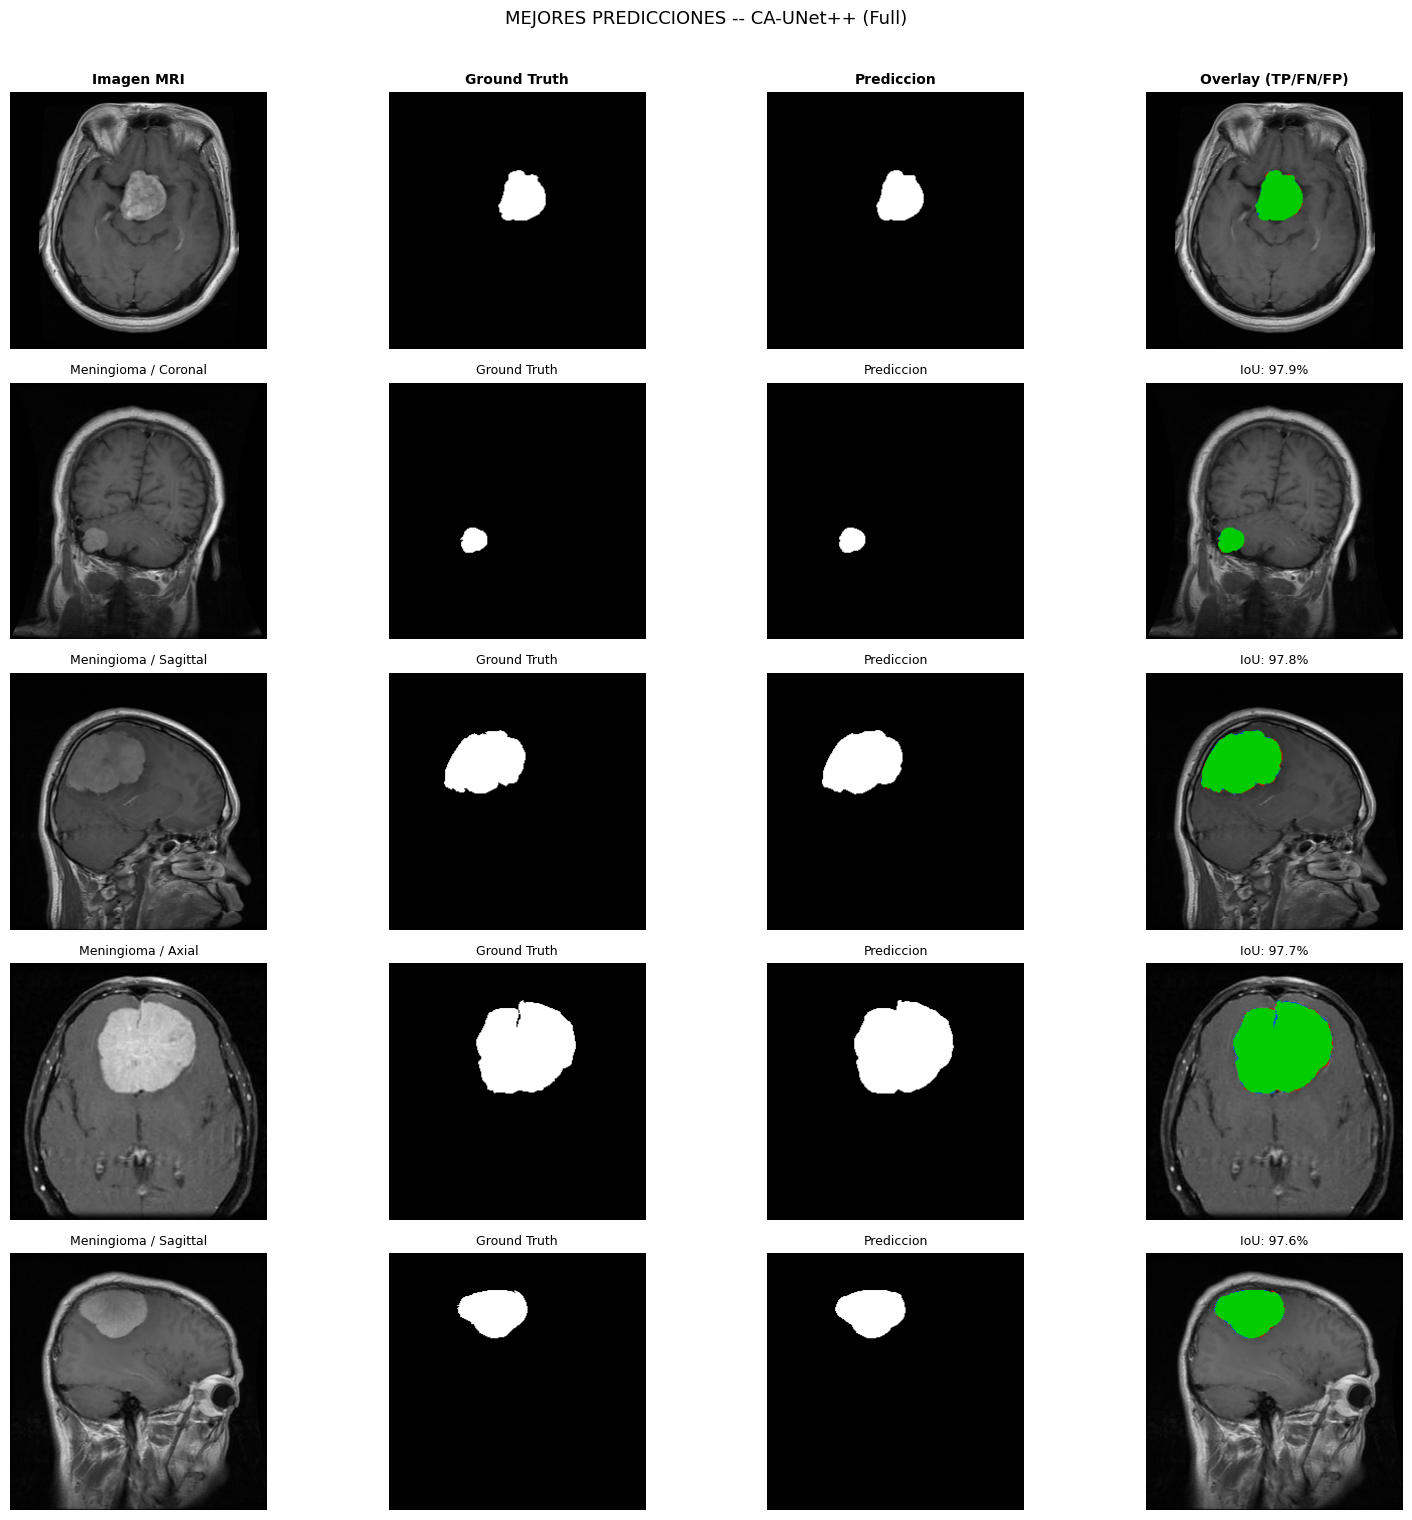

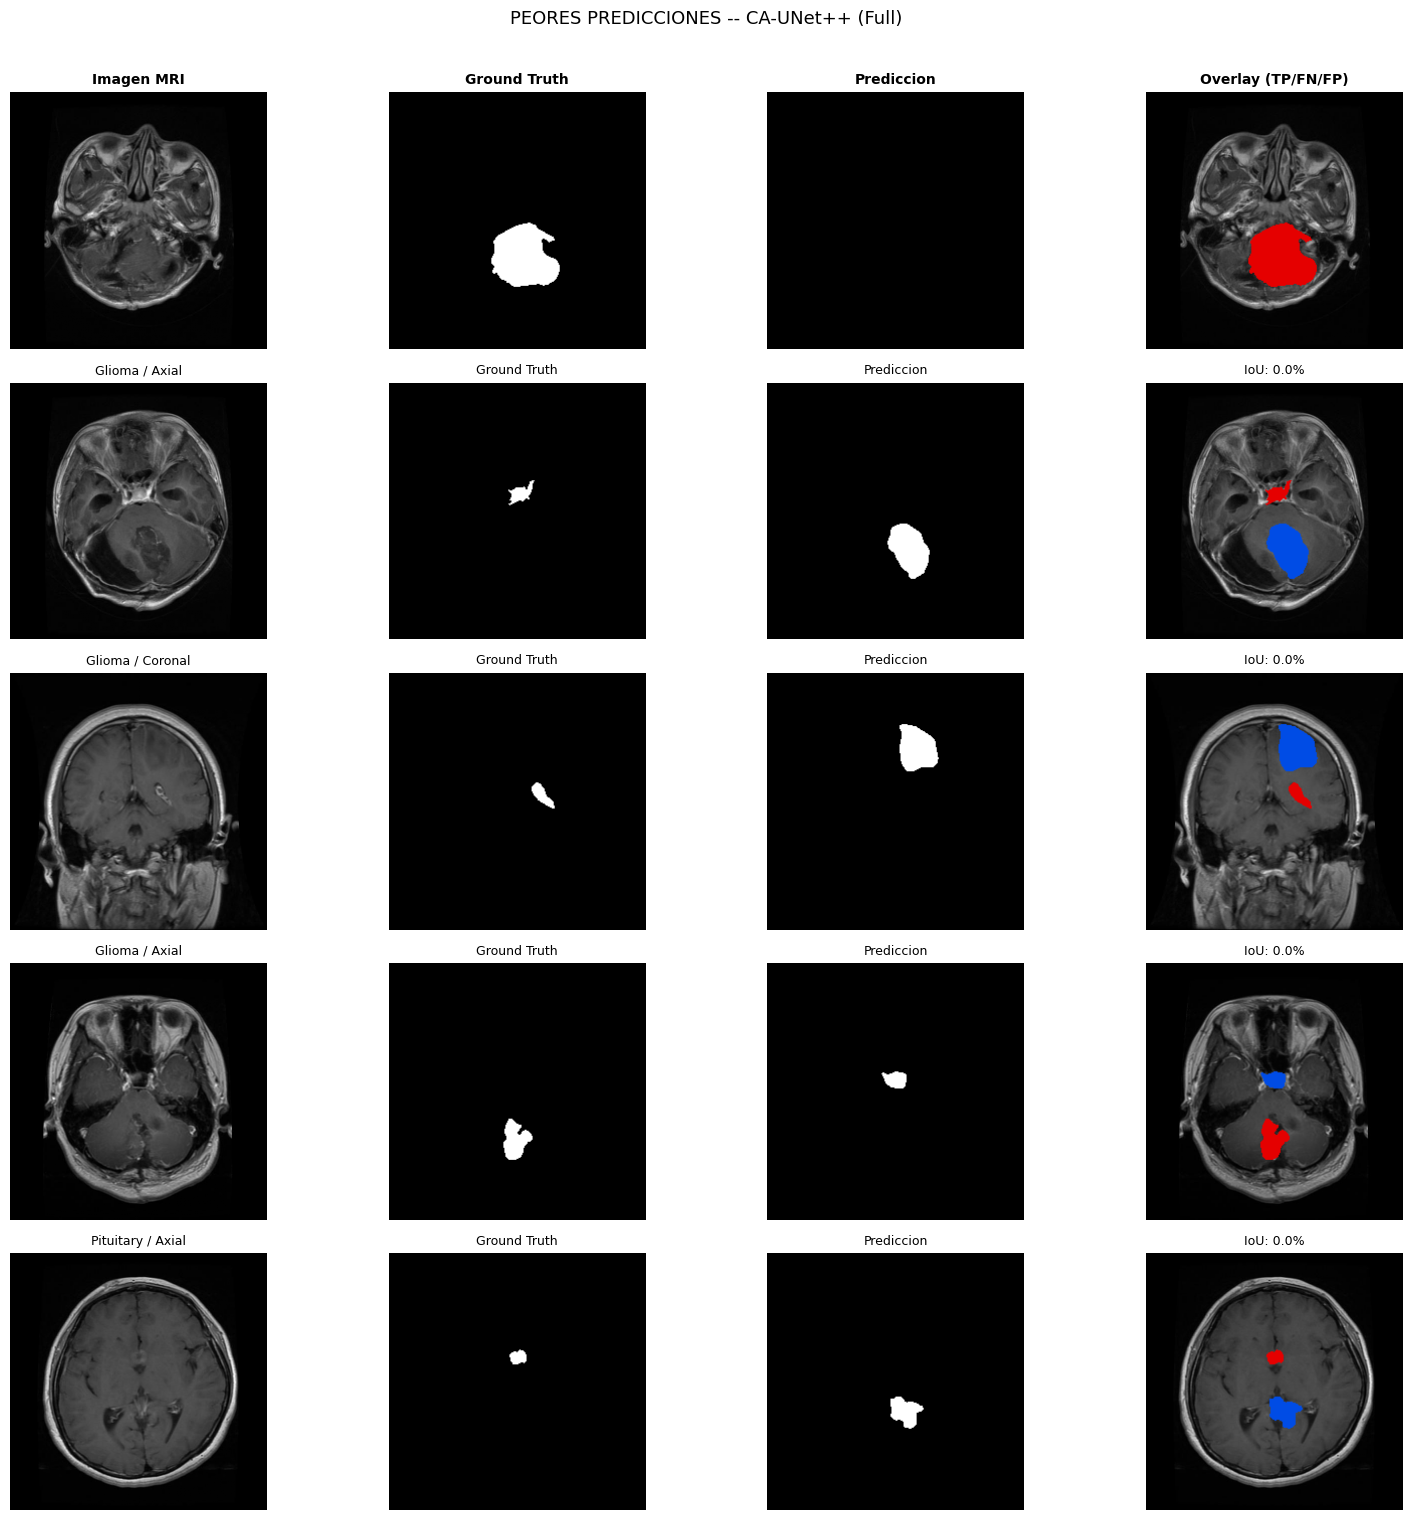

In [42]:
# ============================================================
# 13. CONSOLIDACION Y VISUALIZACION BEST/WORST POR VARIANTE
# ============================================================

print("=" * 65)
print("  RESULTADOS CONSOLIDADOS EN TEST -- MODELO PROPUESTO")
print("=" * 65)
print(f"  Variantes evaluadas: {list(ablation_summaries.keys())}\n")

for model_name, build_fn in ABLATION_MODELS:
    if model_name not in ablation_results:
        print(f"  {model_name}: resultados no disponibles, saltar.")
        continue

    print(f"\n{'─'*65}")
    print(f"  Best/Worst -- {model_name}")
    print(f"{'─'*65}")

    model = load_checkpoint(build_fn, model_name, base_path, device)
    visualize_best_worst(
        model, ablation_results[model_name], df_test, device, model_name, n=5)

    del model
    torch.cuda.empty_cache()
